In [1]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import pearsonr, linregress, zscore, normaltest, gaussian_kde
from diptest import diptest
import re
import requests
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests


In [2]:
# Dictionary of Uniprot IDs for each structure in Rocklin1
uniprot_ids = {
    "PIN1": "Q13526",
    "spg": "P06654",
    "FYN": "P06241",
    "rplI": "P02417",
    "THO1": "P40040",
    "CPA2": "P48052",
    "PRPF40A": "O75400",
    #"sucB": "P0AFG6",
    #"VIL1": "P02640",
    #"YAP1": "P46937",    
}

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None) 

In [4]:
plt.rcParams.update({'font.size': 14})

In [5]:
def load_aligned_data(uniprot_ids, pipeline_dir, rocklin_dir=None):
    pipeline_data = {}
    rocklin_data = {}

    for gene, uniprot_id in uniprot_ids.items():
        #  pipeline 
        pipe_file = os.path.join(pipeline_dir, f"pipeline_{uniprot_id}.csv")
        if os.path.exists(pipe_file):
            df = pd.read_csv(pipe_file)

            df["res"] = df["res"].astype(int)

            # build variant column
            df["variant_rebased"] = (df["mut_from_rebased"].astype(str) + df["res"].astype(str) + df["mut_to"].astype(str))

            df["uniprot_id"] = uniprot_id
            pipeline_data[uniprot_id] = df

        #  rocklin 
        rock_file = os.path.join(rocklin_dir, f"Rocklin1_{uniprot_id}.csv")
        if os.path.exists(rock_file):
            df = pd.read_csv(rock_file)

            df["res"] = df["res"].astype(int)
            df["variant"] = (df["mut_from"].astype(str) + df["res"].astype(str) + df["mut_to"].astype(str))
    
            df["uniprot_id"] = uniprot_id
            rocklin_data[uniprot_id] = df

    return pipeline_data, rocklin_data


In [6]:
pipeline_dir = "../Output/Aligned_dfs"
rocklin_dir  = "../Output/Aligned_dfs"

pipeline_data, Rocklin1_data = load_aligned_data(
    uniprot_ids,
    pipeline_dir,
    rocklin_dir,
)


In [7]:
# Take the mean ddg to average across homomeric chains in pipeline structures

pipeline_data_meanhomo = defaultdict(dict)

for uniprot_id, df in pipeline_data.items():
    # Group by pdb_id + variant to take mean ddg
    for pdb_id, pdb_df in df.groupby("pdb_id"):
        mean_df = (
            pdb_df.groupby(["uniprot_id", "pdb_id", "variant_rebased"], as_index=False) 
                  .agg({
                      "ddg_rebased": "mean",
                      "mut_from_rebased": "first",
                      "mut_to": "first",
                      "res": "first",
                  })
        )
        pipeline_data_meanhomo[uniprot_id][pdb_id] = mean_df


In [8]:
# Remove extreme Rocklin energies

for uniprot_id, df in Rocklin1_data.items():
    Rocklin1_data[uniprot_id] = df[df["deltaG"] > -1].copy()


#### Combine datasets on Rocklin variants

In [9]:
# Combine pipepline and Rocklin1 datasets for the gene

combined_data = {}

for gene, uniprot_id in uniprot_ids.items():
    # Get all pipeline PDB-level ddG for this UniProt
    pipeline_dict = pipeline_data_meanhomo.get(uniprot_id, {})
    pipeline_all = pd.concat(pipeline_dict.values(), ignore_index=True)

    # Get Rocklin1 variant-level data for this gene
    rocklin_df = Rocklin1_data.get(uniprot_id)
    rocklin_vars = rocklin_df[["variant", "deltaG", "prev_dG"]]

    # Merge 
    combined_df = pipeline_all.merge(rocklin_vars, left_on="variant_rebased", right_on="variant", how="left")

    # Drop rows where Rocklin ddg is NaN
    combined_df = combined_df.dropna(subset=["deltaG"])

    combined_data[uniprot_id] = combined_df




In [10]:
rows = []
for g, uid in uniprot_ids.items():
    df = combined_data.get(uid)
    if df is None or df.empty:
        continue
    n_variants = df["variant_rebased"].nunique()
    n_structures = df["pdb_id"].nunique()
    structures_per_variant = df.groupby("variant_rebased")["pdb_id"].nunique()
    rows.append({
        "gene": g,
        "n_variants": n_variants,
        "n_structures": n_structures,
        "median_structures_per_variant": structures_per_variant.median(),
        "min_structures_per_variant": structures_per_variant.min(),
        "max_structures_per_variant": structures_per_variant.max(),       
    })

coverage_summary = pd.DataFrame(rows).sort_values("n_variants")
print(coverage_summary.to_string(index=False))

   gene  n_variants  n_structures  median_structures_per_variant  min_structures_per_variant  max_structures_per_variant
   CPA2          20             2                            1.0                           1                           2
   THO1          28             3                            3.0                           3                           3
   rplI          42             5                            5.0                           4                           5
PRPF40A          47             4                            4.0                           1                           4
   PIN1          60            81                           74.0                          43                          80
    FYN          80            37                           37.0                          36                          37
    spg         886            28                           27.0                          17                          28


### Analysis - PIN1

In [15]:
gene = "PIN1"
uniprot_id = uniprot_ids[gene]

Note: Tsuboyama et al present an 'unfolded state model' and so the Rocklin DDG energies are unfolding

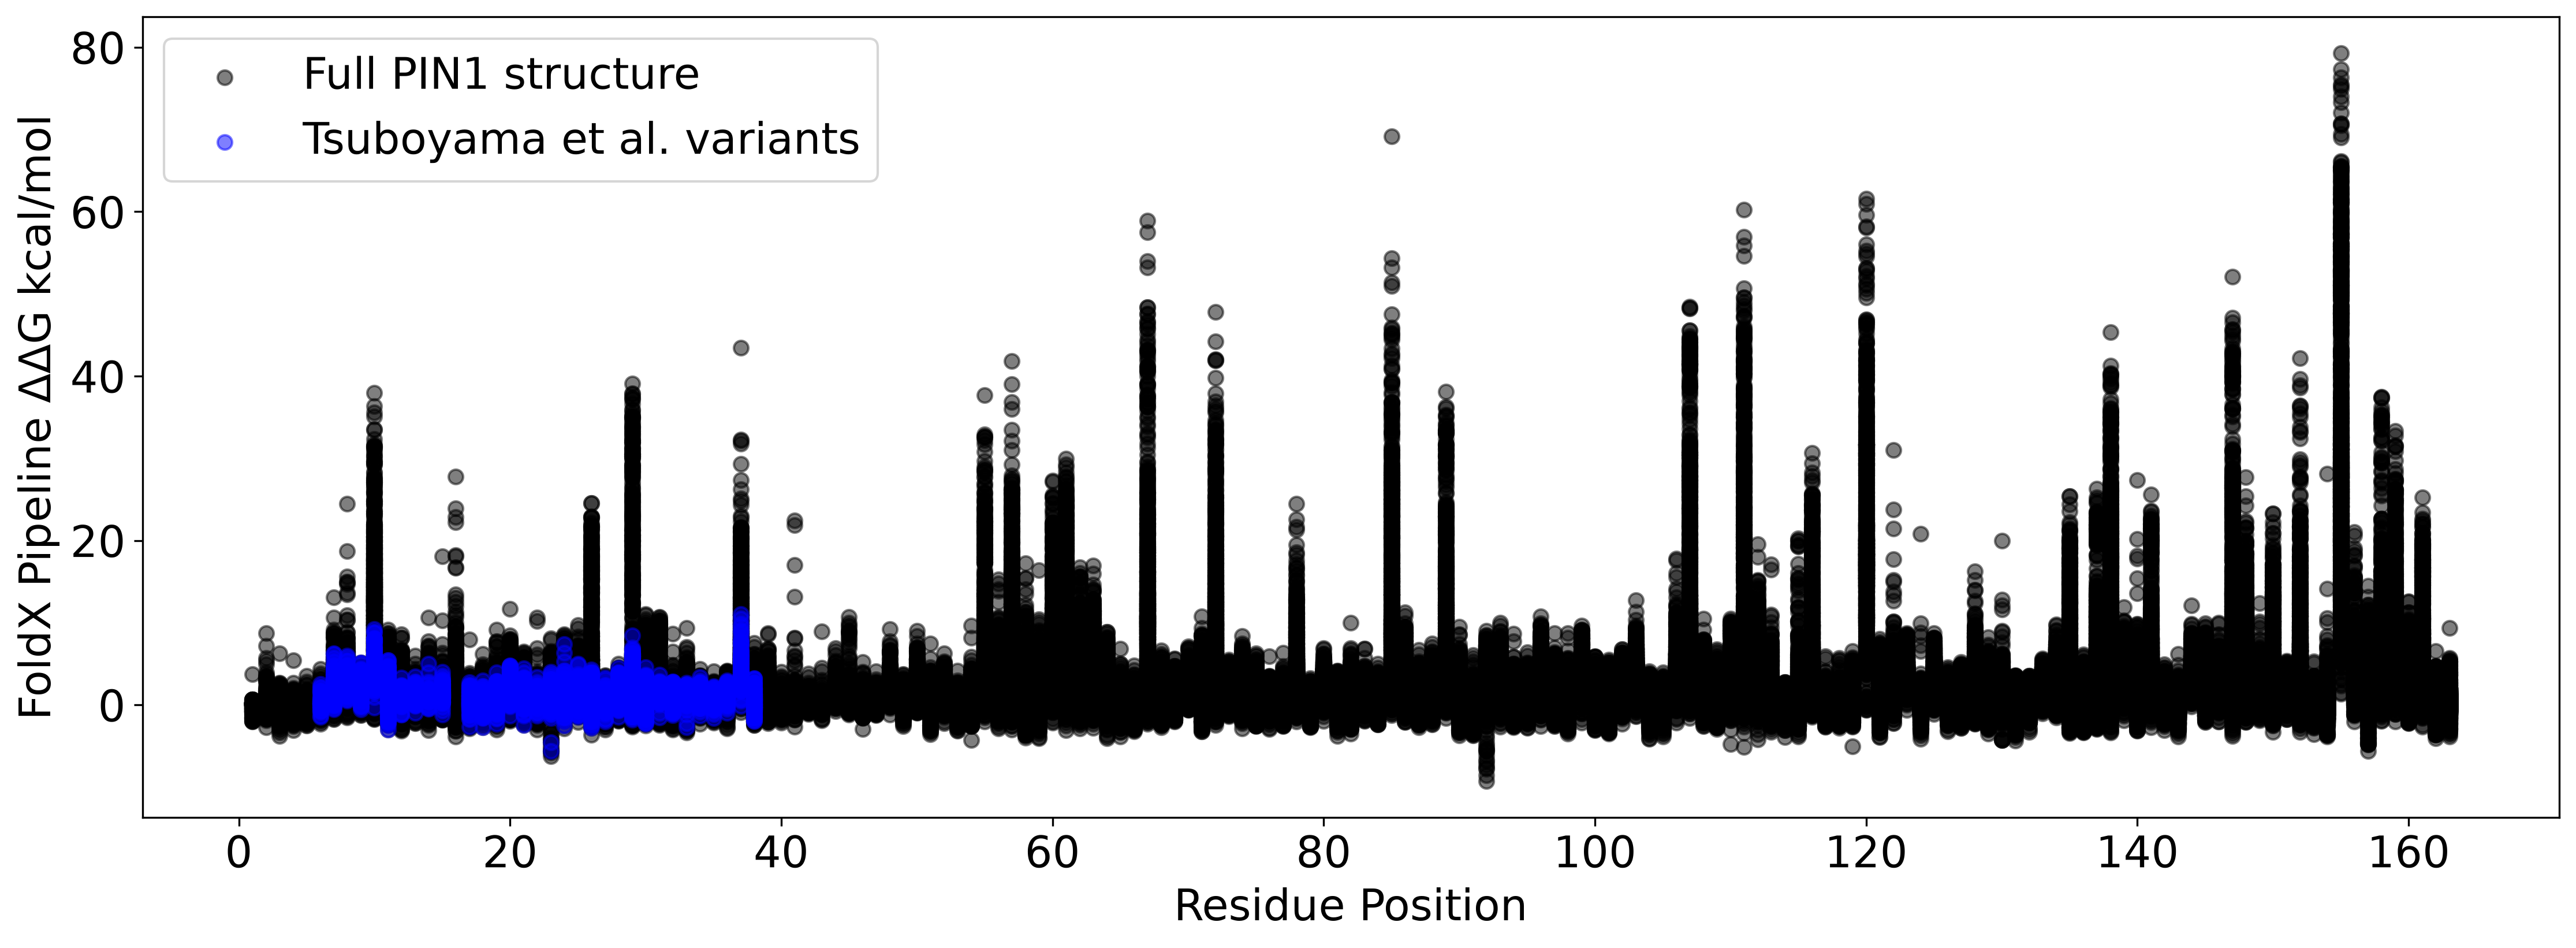

In [16]:
# Plot scatter of energies across gene sequence

plt.figure(figsize=(18, 6), dpi=300)
plt.rcParams.update({'font.size': 18})

plt.scatter(pipeline_data[uniprot_id]['res'], pipeline_data[uniprot_id]['ddg_rebased'], label = f'Full {gene} structure', color = 'black', alpha=0.5)
plt.scatter(combined_data[uniprot_id]['res'], combined_data[uniprot_id]['ddg_rebased'], label = 'Tsuboyama et al. variants', color = 'blue', alpha=0.5)
plt.xlabel('Residue Position')
plt.ylabel('FoldX Pipeline ΔΔG kcal/mol')
plt.legend()
plt.savefig("../Figures/Figure_3a.png", dpi=300, bbox_inches="tight")

plt.show()


#### Correlation - all energies

In [17]:
# Correlation coefficients - all energies

pearson_corr, _ = pearsonr(-combined_data[uniprot_id]['deltaG'], combined_data[uniprot_id]['ddg_rebased'])
print(f"PCC all energies:", pearson_corr, _)

pearson_corr, _ = pearsonr(-combined_data[uniprot_id]['prev_dG'], combined_data[uniprot_id]['ddg_rebased'])
print(f"PCC all energies prev_dG:", pearson_corr, _)

# 

PCC all energies: 0.29943143205417233 1.6514879976263777e-92
PCC all energies prev_dG: 0.2963847438967927 1.3772702613996235e-90


#### Linear regression 

Linear regression, outlier classification, problem mutation identification

In [18]:
def fit_fn(x):
    slope, intercept, r_value, p_value, std_err = linregress(x, combined_data[uniprot_id]['ddg_rebased'])
    print(f" {gene} Slope = {slope:.3f} ± {std_err:.3f}")
    return slope * x + intercept

In [19]:
# Identify outliers as distance from LOBF outside 95% confidence interval for all mutations
# For spg and FYN, due to extreme negative DDG rebasing for some structures, only consider positive distances
distances = np.abs(combined_data[uniprot_id]['ddg_rebased'].values - fit_fn(combined_data[uniprot_id]['deltaG'].values)) # FYN and spg -ve distances are extreme rebasing

# Compute z-scores
combined_data[uniprot_id]["z_scores"] = zscore(distances, nan_policy="omit")

# Threshold for 95% CI
outlier_threshold = 1.96

# Identify outliers
outliers = combined_data[uniprot_id].loc[combined_data[uniprot_id]["z_scores"] > outlier_threshold] 


 PIN1 Slope = -0.606 ± 0.029


In [20]:
print(f"{gene}")

print("Unique Structures:", len(combined_data[uniprot_id]['pdb_id'].unique()))
print("Unique Residues:", len(combined_data[uniprot_id]['res'].unique()))
print("Unique Mutations:", len(combined_data[uniprot_id]['variant_rebased'].unique()))




PIN1
Unique Structures: 81
Unique Residues: 32
Unique Mutations: 60


In [22]:
counts = outliers["variant"].value_counts()

cum_frac = counts.cumsum().div(len(outliers))

x_index = cum_frac.gt(0.695).values.argmax() + 1

top_mutations = counts.index[:x_index].tolist()

print(f"Top {x_index} problematic mutations:", top_mutations)

fraction = counts.iloc[:x_index].sum() / len(outliers)
print(f"Fraction of outliers:", fraction)


Top 4 problematic mutations: ['T29D', 'G10A', 'P37I', 'W11F']
Fraction of outliers: 0.6954314720812182


#### dip test / normality test with FDR-BH correction

In [23]:

records = []
for mutation, group in combined_data[uniprot_id].groupby("variant"):
    data = group["ddg_rebased"].dropna().to_numpy()
    if len(data) < 3:
        continue
    dip_stat, dip_p = diptest(data)
    norm_stat, norm_p = normaltest(data)
    records.append({"variant": mutation, "n": len(data), "data": data,
                     "dip_p": dip_p, "norm_p": norm_p})

dip_ps = [r["dip_p"] for r in records]
norm_ps = [r["norm_p"] for r in records]

dip_reject, dip_p_adj, _, _ = multipletests(dip_ps, alpha=0.05, method="fdr_bh")
norm_reject, norm_p_adj, _, _ = multipletests(norm_ps, alpha=0.05, method="fdr_bh")

for r, p_adj, rej in zip(records, dip_p_adj, dip_reject):
    r["dip_p_adj"], r["multimodal_corrected"] = p_adj, rej
for r, p_adj, rej in zip(records, norm_p_adj, norm_reject):
    r["norm_p_adj"], r["non_normal_corrected"] = p_adj, rej

n_total = len(records)
n_multimodal_raw = sum(r["dip_p"] < 0.05 for r in records)
n_multimodal_fdr = sum(r["multimodal_corrected"] for r in records)
n_nonnormal_raw = sum(r["norm_p"] < 0.05 for r in records)
n_nonnormal_fdr = sum(r["non_normal_corrected"] for r in records)

print(f"{gene}: {n_total} substitutions tested")
print(f"Multimodal — raw p<0.05: {n_multimodal_raw}/{n_total}  |  FDR-BH corrected: {n_multimodal_fdr}/{n_total}")
print(f"Non-normal — raw p<0.05: {n_nonnormal_raw}/{n_total}  |  FDR-BH corrected: {n_nonnormal_fdr}/{n_total}")
print("Multimodal (raw):", [r["variant"] for r in records if r["dip_p"] <= 0.05])
print("Multimodal (FDR-corrected):", [r["variant"] for r in records if r["multimodal_corrected"]])
print("Non-normal (raw):", [r["variant"] for r in records if r["norm_p"] <= 0.05])
print("Non-normal (FDR-corrected):", [r["variant"] for r in records if r["non_normal_corrected"]])

PIN1: 60 substitutions tested
Multimodal — raw p<0.05: 1/60  |  FDR-BH corrected: 0/60
Non-normal — raw p<0.05: 13/60  |  FDR-BH corrected: 8/60
Multimodal (raw): ['T29D']
Multimodal (FDR-corrected): []
Non-normal (raw): ['F25A', 'F25Y', 'G20A', 'L7V', 'Q33A', 'R14A', 'R17A', 'T29D', 'Y23A', 'Y23L', 'Y24F', 'Y24L', 'Y24W']
Non-normal (FDR-corrected): ['F25Y', 'L7V', 'Q33A', 'R14A', 'T29D', 'Y23A', 'Y23L', 'Y24W']


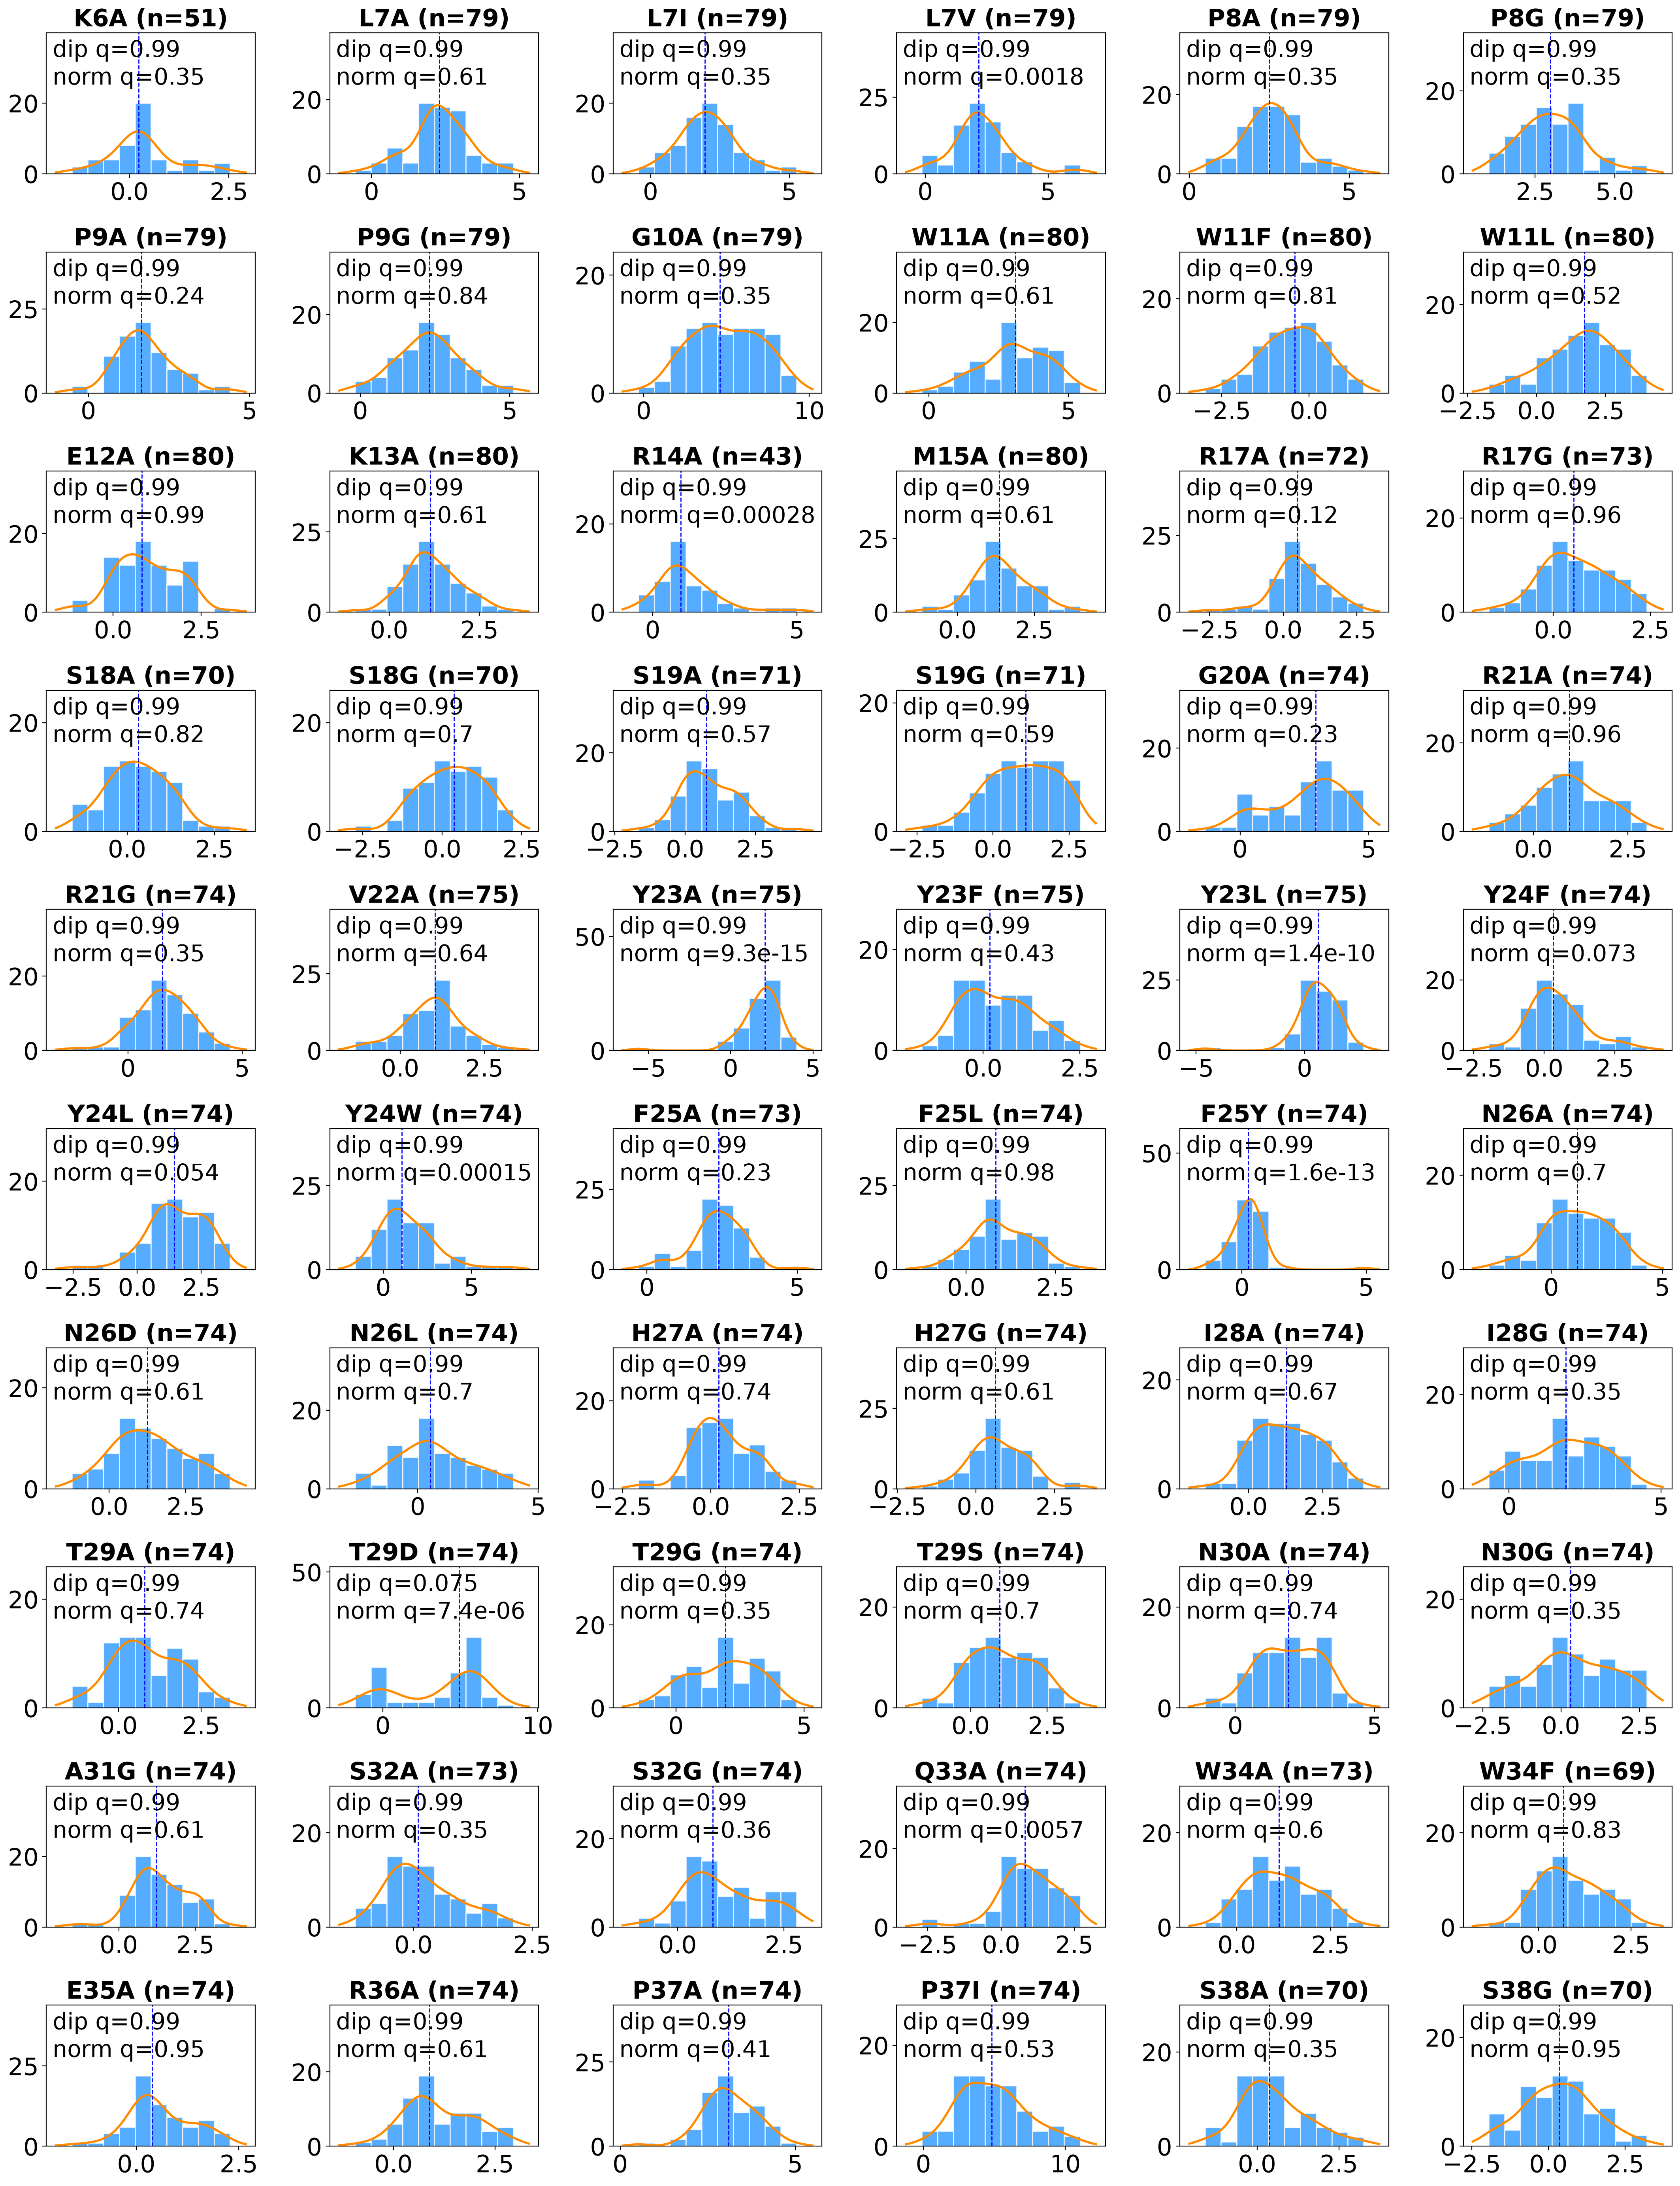

In [73]:

def residue_number(variant):
    m = re.search(r"\d+", variant)
    return int(m.group()) if m else float("inf")

# BH-FDR correction: one family per test, across substitutions for this gene
dip_reject, dip_q, _, _ = multipletests([r["dip_p"] for r in records],
                                        alpha=0.05, method="fdr_bh")
norm_reject, norm_q, _, _ = multipletests([r["norm_p"] for r in records],
                                          alpha=0.05, method="fdr_bh")
for r, dq, dr, nq, nr in zip(records, dip_q, dip_reject, norm_q, norm_reject):
    r["dip_q"], r["multimodal_corrected"] = dq, bool(dr)
    r["norm_q"], r["nonnormal_corrected"] = nq, bool(nr)

# Figure
records_sorted = sorted(records, key=lambda r: residue_number(r["variant"]))
n = len(records_sorted)
ncols = 6
nrows = int(np.ceil(n / ncols))
nbins = 10

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 2.8), dpi=200)
axes = axes.flatten()

for ax, r in zip(axes, records_sorted):
    x = np.asarray(r["data"], dtype=float)
    x = x[~np.isnan(x)]

    counts, edges, _ = ax.hist(x, bins=nbins, color="dodgerblue", alpha=0.75,
                               edgecolor="white")
    bin_width = edges[1] - edges[0]

    # KDE overlay, scaled to counts (Scott's rule bandwidth)
    if len(x) > 2 and np.ptp(x) > 0:
        kde = gaussian_kde(x)
        grid = np.linspace(x.min() - 0.1 * np.ptp(x), x.max() + 0.1 * np.ptp(x), 300)
        ax.plot(grid, kde(grid) * len(x) * bin_width, color="darkorange", linewidth=2)

    ax.axvline(np.median(x), color="blue", linestyle="--", linewidth=1)

    # headroom above the bars
    ax.set_ylim(top=ax.get_ylim()[1] * 1.9)

    flagged_fdr = r["multimodal_corrected"]   # significant after correction
    flagged_nominal = r["dip_p"] <= 0.05      # nominal p only

    ax.set_title(f"{r['variant']} (n={r['n']})", fontsize=22, fontweight="bold",
                 color="crimson" if flagged_fdr else "black")
    ax.text(0.03, 0.97,
           # f"dip p={r['dip_p']:.2g}\n"
            f"dip q={r['dip_q']:.2g}\n"
            #f"norm p={r['norm_p']:.2g}\n"
            f"norm q={r['norm_q']:.2g}",
            transform=ax.transAxes, fontsize=21, va="top", color="k",
            bbox=dict(facecolor="white", alpha=0, edgecolor="none", pad=1.5))
    ax.tick_params(labelsize=22)

    # solid red border = FDR-significant; dashed red border = nominal p <= 0.05 only
    """
    if flagged_fdr or flagged_nominal:
        for spine in ax.spines.values():
            spine.set_edgecolor("crimson")
            spine.set_linewidth(1.8)
            spine.set_linestyle("-" if flagged_fdr else "--")"""

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.savefig("../Figures/Figure_S2.png", dpi=300, bbox_inches="tight")
plt.show()



#### Linear regression with median ddgs ex problem variants

In [25]:
# Aggregate pipeline energies by median

combined_data_median = {}

combined_data_median[uniprot_id] = combined_data[uniprot_id].groupby('variant_rebased', as_index=False).agg({
    'ddg_rebased': 'median',
    'deltaG': 'first',
    'prev_dG': 'first'
})





In [26]:
# Aggregate by median ex problematic mutations
combined_data_median_ex = {}

combined_data_median_ex[uniprot_id] = (
    combined_data[uniprot_id]
    [~combined_data[uniprot_id]['variant_rebased'].isin(top_mutations)]
    .groupby('variant_rebased', as_index=False)
    .agg({
        'ddg_rebased': 'median',
        'deltaG': 'first',
        'prev_dG': 'first'
    })
)


combined_data_median_problem = {}

combined_data_median_problem[uniprot_id] = (
    combined_data[uniprot_id]
    [combined_data[uniprot_id]['variant_rebased'].isin(top_mutations)]
    .groupby('variant_rebased', as_index=False)
    .agg({
        'ddg_rebased': 'median',
        'deltaG': 'first',
        'prev_dG': 'first'
    })
)

In [27]:
def fit_fn_median(x):
    slope, intercept, r_value, p_value, std_err = linregress(x, combined_data_median_ex[uniprot_id]['ddg_rebased'])
    print(f" {gene} Slope medians = {slope:.3f} ± {std_err:.3f}")
    return slope * x + intercept

 PIN1 Slope medians = -0.623 ± 0.113


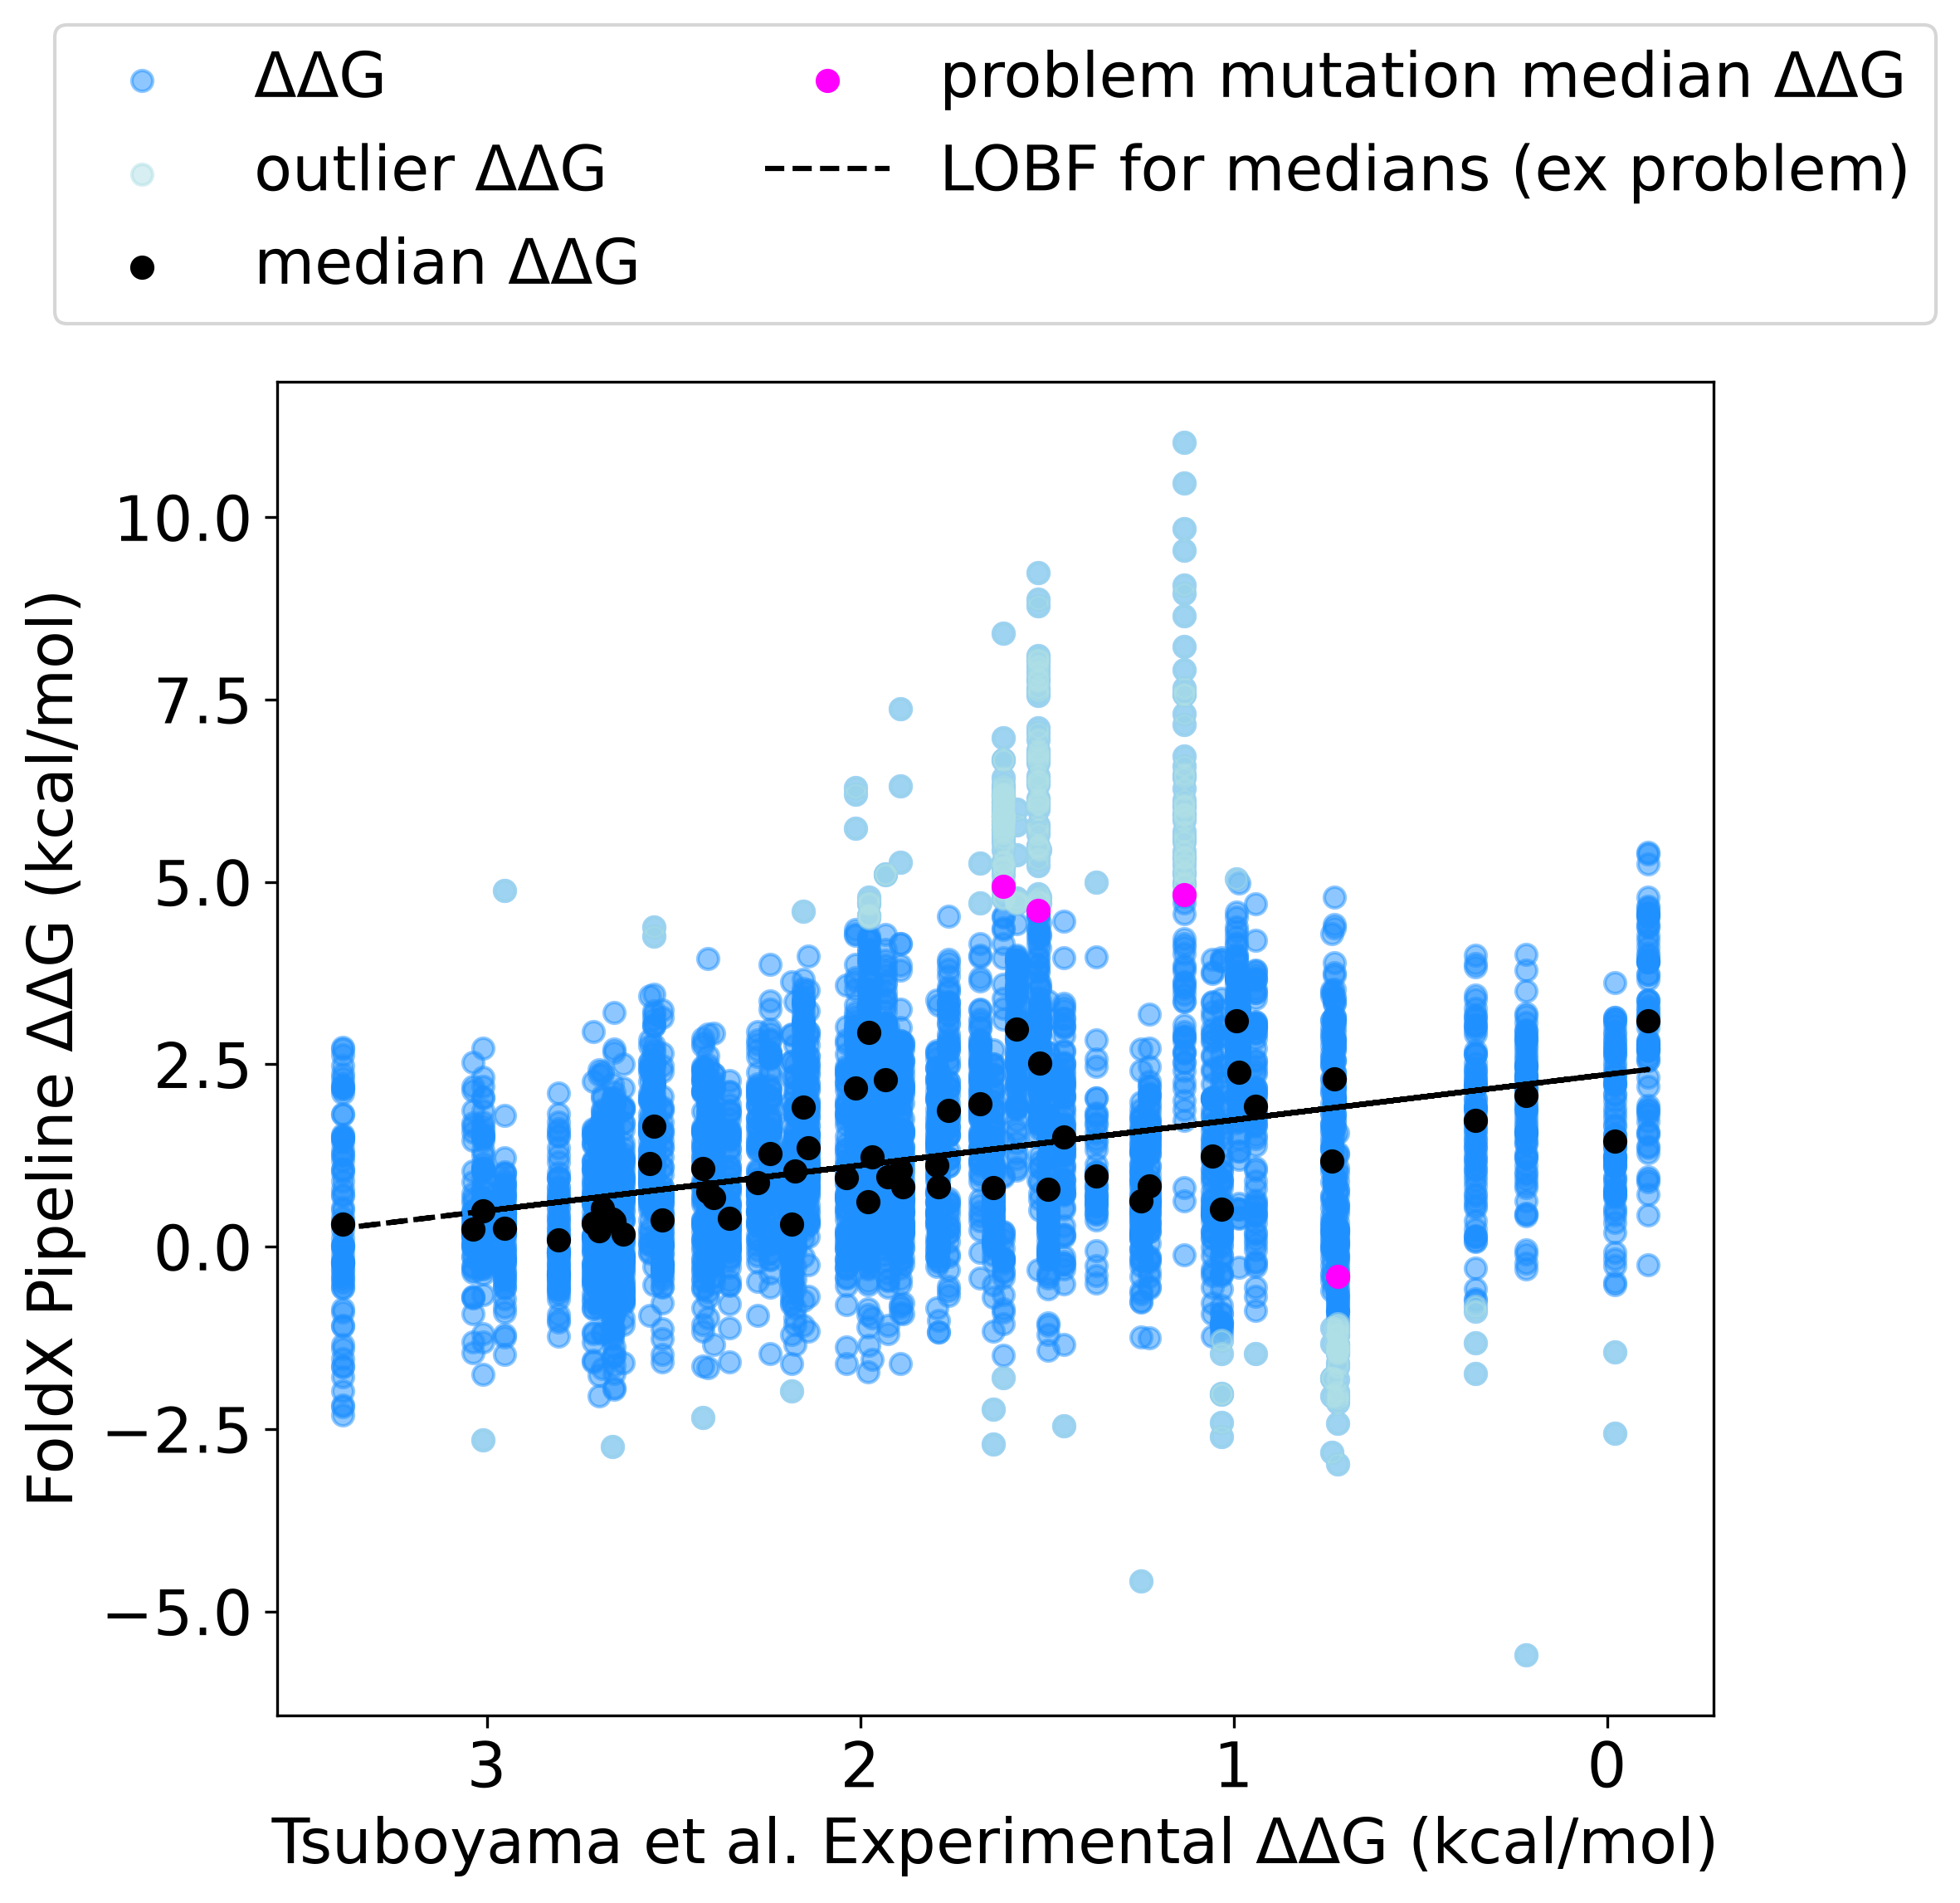

In [34]:
plt.figure(figsize=(8, 8), dpi=300)
plt.rcParams.update({'font.size': 18})

# Plot all energies
plt.scatter(combined_data[uniprot_id]['deltaG'], combined_data[uniprot_id]['ddg_rebased'],
            label='ΔΔG', color='dodgerblue', alpha=0.5)

# Highlight outliers
plt.scatter(outliers['deltaG'], outliers['ddg_rebased'],
            color='powderblue', label='outlier ΔΔG', alpha=0.5)

# Plot median (ex problem)
plt.scatter(combined_data_median_ex[uniprot_id]['deltaG'], combined_data_median_ex[uniprot_id]['ddg_rebased'],
            label='median ΔΔG', color='black')


# Highlight problem medians
plt.scatter(combined_data_median_problem[uniprot_id]['deltaG'], combined_data_median_problem[uniprot_id]['ddg_rebased'],
            label='problem mutation median ΔΔG', color='magenta')
#for _, row in combined_data_median_problem[uniprot_id].iterrows():plt.text(row['deltaG'], row['ddg'], row['variant'], fontsize=6, ha='right', va='bottom')


# Plot LOBF line for median ex problem
plt.plot(
    combined_data_median_ex[uniprot_id]['deltaG'],
    fit_fn_median(combined_data_median_ex[uniprot_id]['deltaG']),
    '--k', label='LOBF for medians (ex problem)'
)

#plt.ylim(-5, 60)
plt.xlim(plt.xlim()[1], plt.xlim()[0]) # reverse x-axis as Tsuboyama present an 'unfolded state model' and so energies are unfolding
plt.xlabel('Tsuboyama et al. Experimental ΔΔG (kcal/mol)')
plt.ylabel('FoldX Pipeline ΔΔG (kcal/mol)')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)
plt.tight_layout()
plt.savefig("../Figures/Figure_1a.png", dpi=300, bbox_inches="tight")
plt.show()



#### Correlation - median energies

In [29]:
# Correlation coefficient - median energies ex problem mutations

pearson_corr, _ = pearsonr(-combined_data_median_ex[uniprot_id]['deltaG'], combined_data_median_ex[uniprot_id]['ddg_rebased'])
print(f"PCC median ex problem:", pearson_corr, _)

pearson_corr, _ = pearsonr(-combined_data_median_ex[uniprot_id]['prev_dG'], combined_data_median_ex[uniprot_id]['ddg_rebased'])
print(f"PCC median ex problem prev_dG:", pearson_corr, _)



PCC median ex problem: 0.6012839873892593 9.559450921265447e-07
PCC median ex problem prev_dG: 0.5446281707934664 1.4287445038637972e-05


#### Confidence interval non outlier energies

In [30]:
def median_bootstrap_ci(x, n_boot=2000, alpha=0.05, random_state=None):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan, np.nan
    rng = np.random.default_rng(random_state)
    boot_meds = [np.median(rng.choice(x, size=len(x), replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boot_meds, [100 * (alpha/2), 100 * (1-alpha/2)])
    med = np.median(x)
    return med, lo, hi, hi - lo

In [31]:
def compute_median_cis(df, value_col="ddg_rebased", substitution_col="variant_rebased",
                       n_boot=2000, alpha=0.05, random_state=None):
    return (
        df.groupby(substitution_col, sort=False)[value_col]
          .apply(lambda x: median_bootstrap_ci(x, n_boot, alpha, random_state))
          .apply(pd.Series, index=["median_boot","median_boot_ci_low",
                                   "median_boot_ci_high","median_boot_ci_width"])
          .assign(n=df.groupby(substitution_col)[value_col].size().values)
          .reset_index()
    )


In [32]:
outlier_threshold = 1.96
non_outliers_df = combined_data[uniprot_id].loc[combined_data[uniprot_id]["z_scores"].abs() <= outlier_threshold] #
 
ci_results = compute_median_cis(non_outliers_df, random_state=42)


In [33]:
print(f"\nGene: {gene}")
print("Median - low:", (ci_results["median_boot"] - ci_results["median_boot_ci_low"]).mean())
print("High - median:", (ci_results["median_boot_ci_high"] - ci_results["median_boot"]).mean())


Gene: PIN1
Median - low: 0.27163341961666665
High - median: 0.3395887482749999


In [ ]:
loo_results = []
variants = combined_data_median_ex[uniprot_id]["variant_rebased"].tolist() if "variant_rebased" in combined_data_median_ex[uniprot_id].columns else combined_data_median_ex[uniprot_id].index.tolist()

full_slope = linregress(median_df["deltaG"], median_df["ddg_rebased"]).slope

for i in range(len(median_df)):
    sub = median_df.drop(median_df.index[i])
    if len(sub) < 3:
        continue
    s = linregress(sub["deltaG"], sub["ddg_rebased"]).slope
    loo_results.append({"dropped_row": i, "slope_without": s, "delta_from_full": s - full_slope})

loo_df = pd.DataFrame(loo_results).sort_values("delta_from_full", key=abs, ascending=False)
print(f"Full median-aggregated slope: {full_slope:.3f}")
print("Top 5 highest-leverage variants (largest slope change when dropped):")
print(loo_df.head(5).to_string(index=False))

### Illustrate distribution of amino acids (Rocklin variants only)

In [35]:
def plot_mutation_counts(counts_all, counts_out, y2label=None, savepath=None):
    # Make sure all mutations are included in both
    all_mutations = sorted(set(counts_all.index) | set(counts_out.index))
    all_counts = counts_all.reindex(all_mutations, fill_value=0)
    out_counts = counts_out.reindex(all_mutations, fill_value=0)
    x = np.arange(len(all_mutations))
    fig, ax1 = plt.subplots(figsize=(6,6), dpi=300)
    plt.rcParams.update({'font.size': 18})
    # Left axis - all variants
    ax1.bar(x - 0.2, all_counts.values, width=0.4, color='black', label='All')
    ax1.set_ylabel('All variants count', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.locator_params(axis='y', nbins=4)
    # Right axis - outliers
    ax2 = ax1.twinx()
    ax2.bar(x + 0.2, out_counts.values, width=0.4, color='blue', label='Outliers')
    ax2.set_ylabel(y2label, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.locator_params(axis='y', nbins=4)
    # X-axis labels
    ax1.set_xticks(x)
    ax1.set_xticklabels(all_mutations)
    ax1.set_xlabel('Amino Acid', color='black')
    if savepath is not None:
        fig.savefig(savepath, bbox_inches='tight')
    plt.show()

In [ ]:
# spg only mut_from
plot_mutation_counts(
    counts_all = combined_data[uniprot_id]['mut_from_rebased'].value_counts(),
    counts_out = combined_data[uniprot_id][combined_data[uniprot_id]['z_scores'] > 1.96]['mut_from_rebased'].value_counts(),
    y2label='Outlier count'
)



In [ ]:
# spg only mut_to
plot_mutation_counts(
    counts_all = combined_data[uniprot_id]['mut_to'].value_counts(),
    counts_out = combined_data[uniprot_id][combined_data[uniprot_id]['z_scores'] > 1.96]['mut_to'].value_counts(),
    y2label='Outlier count'
)

#### Illustrate distribution of amino acids and substitiutions (all variants)

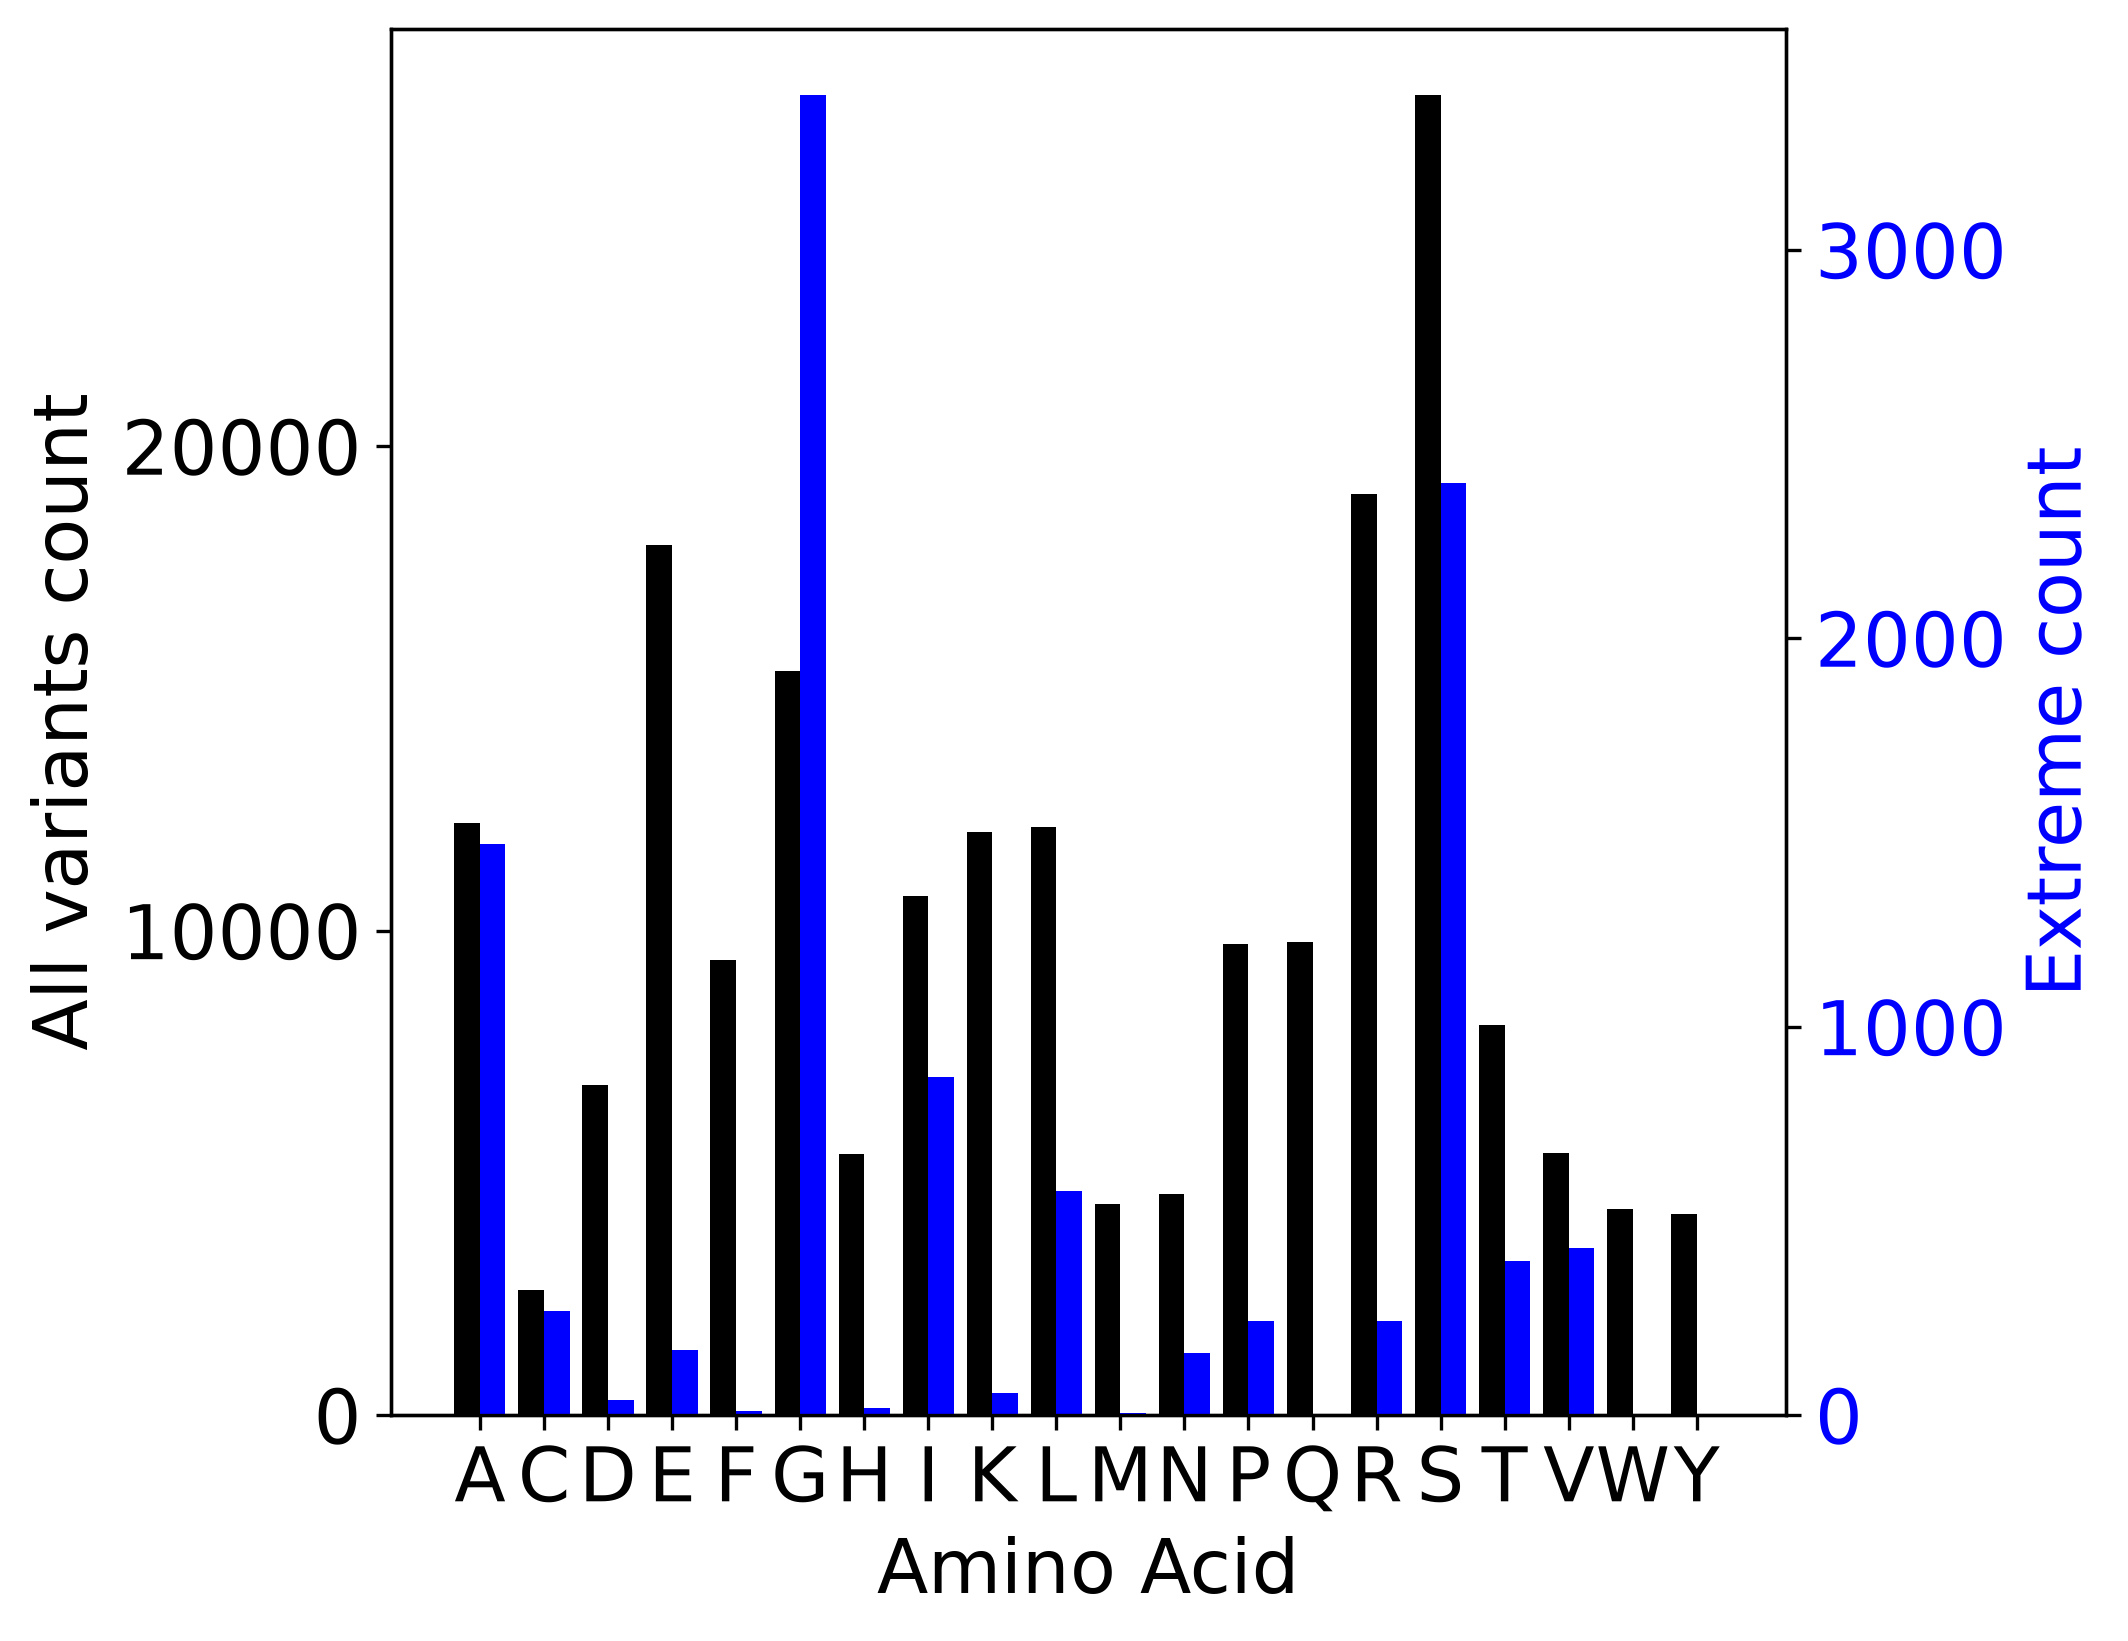

In [36]:
plot_mutation_counts(
    counts_all = pipeline_data[uniprot_id]['mut_from_rebased'].value_counts(),
    counts_out = pipeline_data[uniprot_id]
        .loc[pipeline_data[uniprot_id]['ddg_rebased'] > 10, 'mut_from_rebased']
        .value_counts(),
    y2label='Extreme count'
)


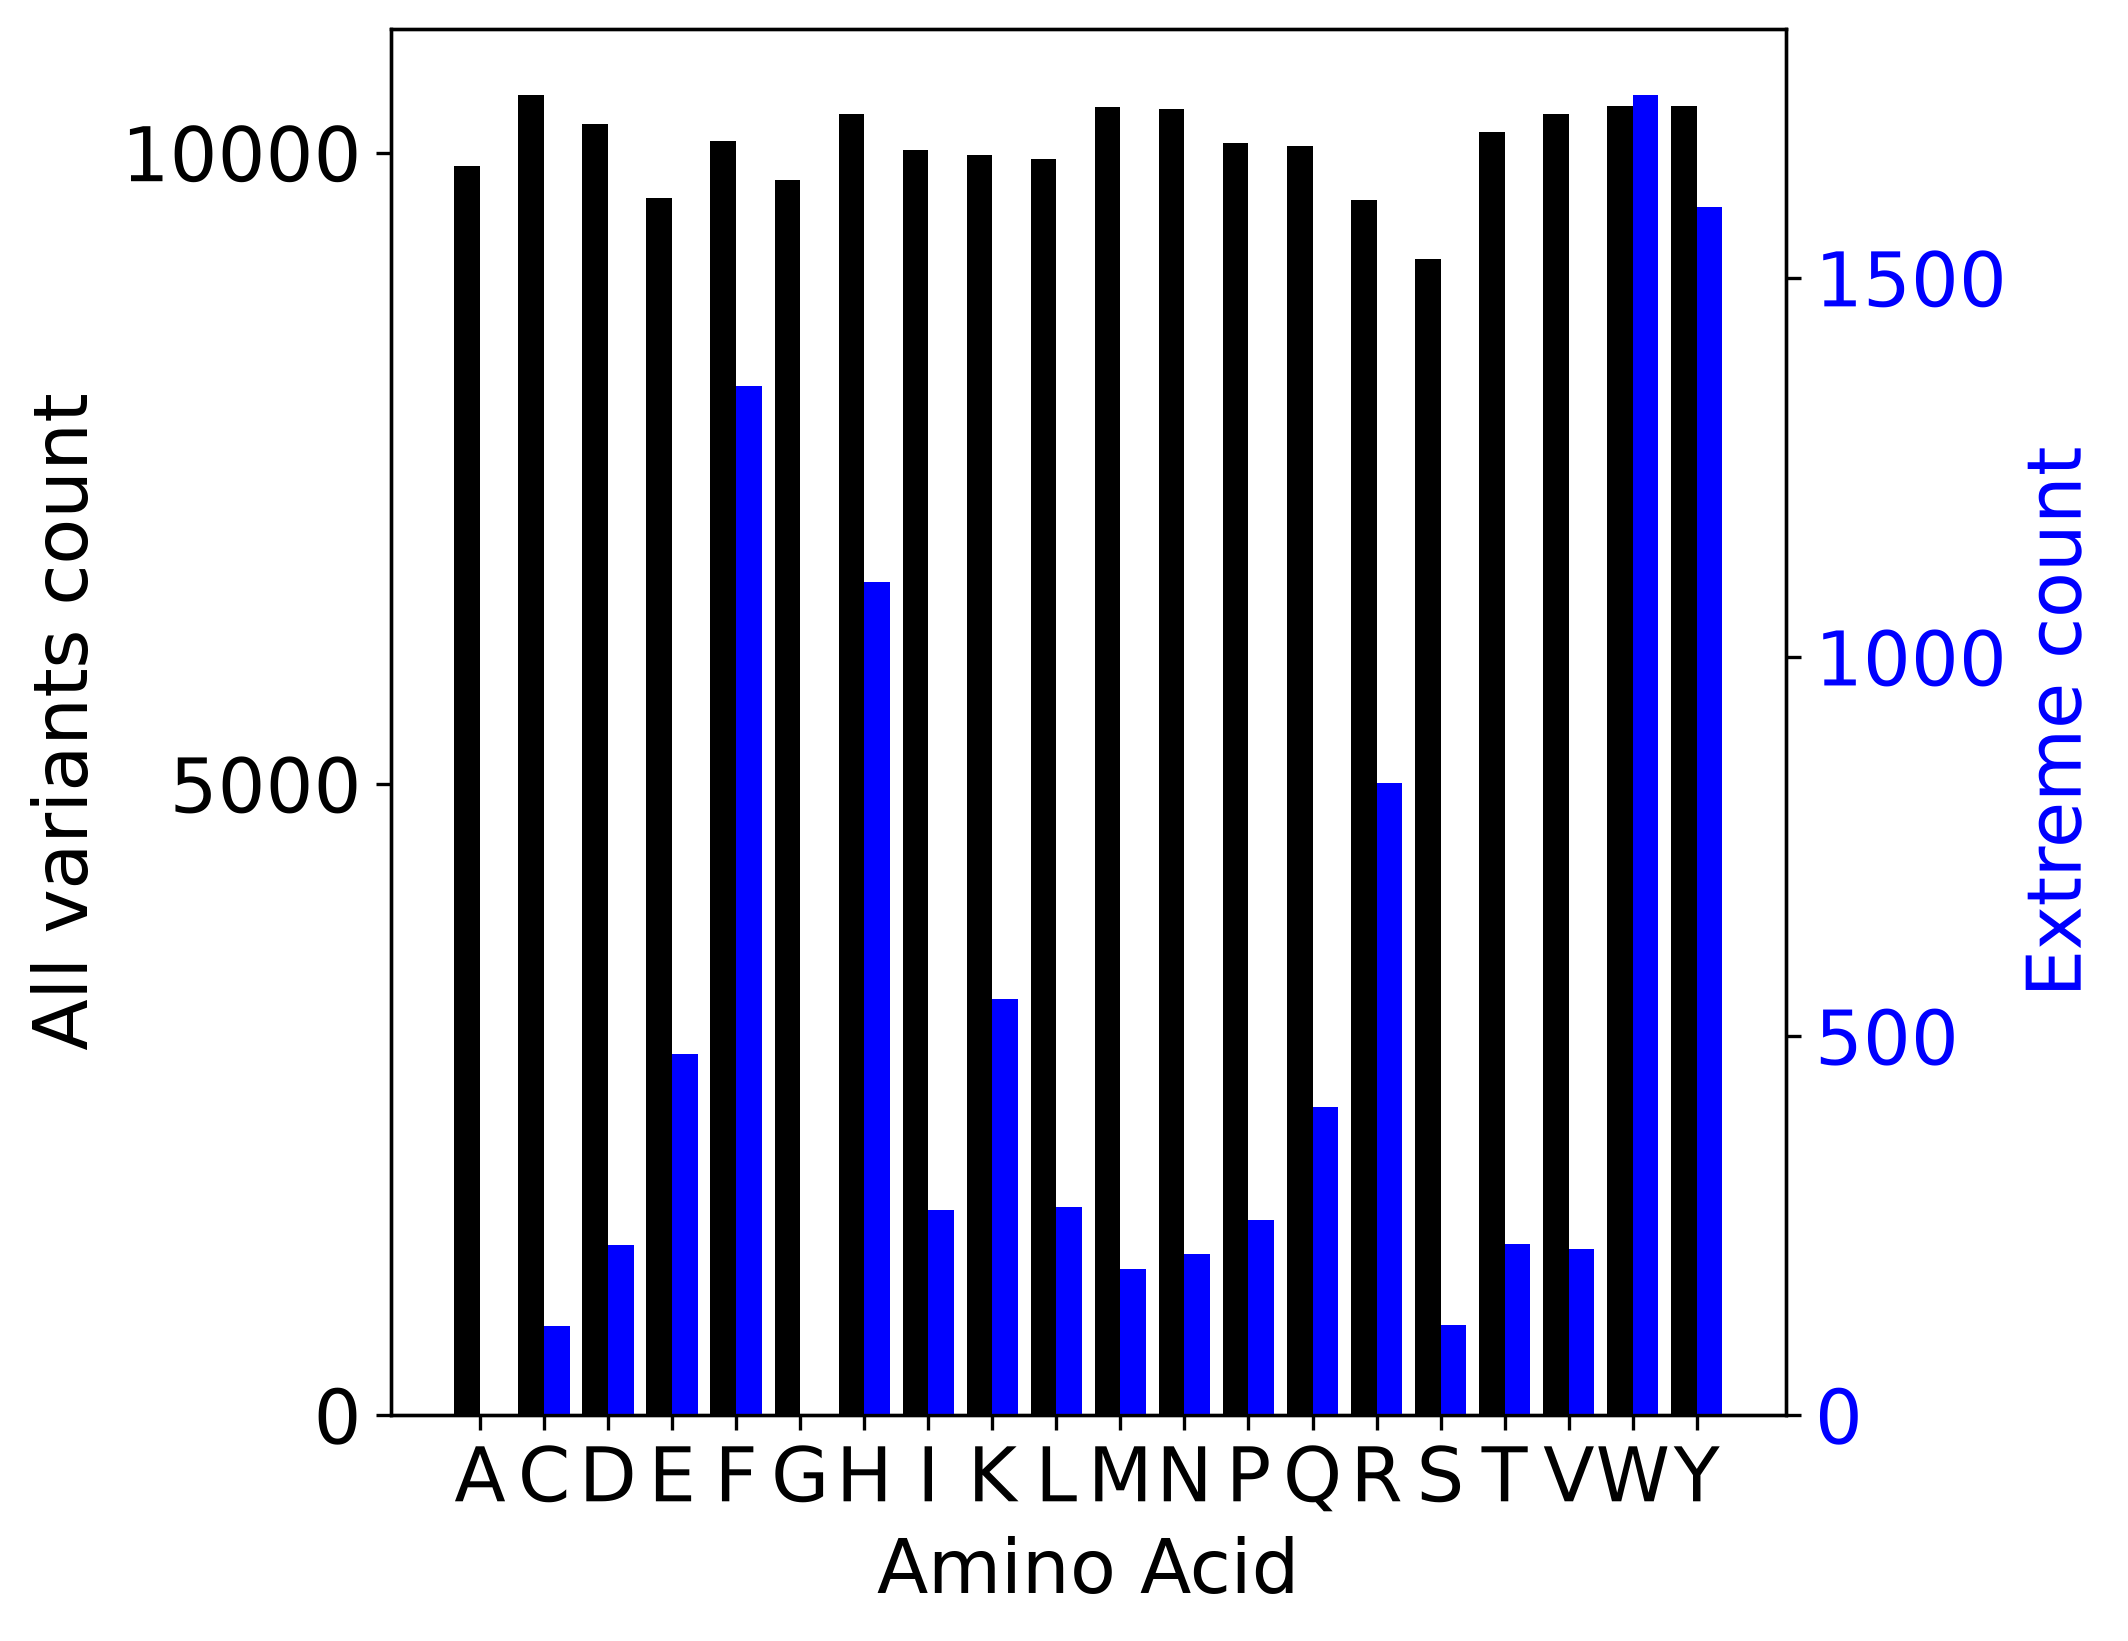

In [37]:
plot_mutation_counts(
    counts_all = pipeline_data[uniprot_id]['mut_to'].value_counts(),
    counts_out = pipeline_data[uniprot_id]
        .loc[pipeline_data[uniprot_id]['ddg'] > 10, 'mut_to']
        .value_counts(),
    y2label='Extreme count',
    savepath = "../Figures/Figure_3b.png"
)





### Disorder analysis (MoreRonn)
#### Get FASTA-formatted sequence below to paste into webpage https://moreronn.org/
Gives MoreRonn score of disorder for each residue. Downloaded file parsed below. 


In [38]:
def get_uniprot_fasta(gene):
    uniprot_id = uniprot_ids[gene]
    url = f'https://www.uniprot.org/uniprot/{uniprot_id}.fasta'
    response = requests.get(url)
    
    if response.status_code == 200:
        return response.text.strip()  # Return full FASTA format
    else:
        return None  

uniprot_fasta_sequence = get_uniprot_fasta(gene)

print(uniprot_fasta_sequence)

>sp|Q13526|PIN1_HUMAN Peptidyl-prolyl cis-trans isomerase NIMA-interacting 1 OS=Homo sapiens OX=9606 GN=PIN1 PE=1 SV=1
MADEEKLPPGWEKRMSRSSGRVYYFNHITNASQWERPSGNSSSGGKNGQGEPARVRCSHL
LVKHSQSRRPSSWRQEKITRTKEEALELINGYIQKIKSGEEDFESLASQFSDCSSAKARG
DLGAFSRGQMQKPFEDASFALRTGEMSGPVFTDSGIHIILRTE


In [39]:
def parse_moreronn_scores(filepath):

    aa_list = []
    score_list = []

    pattern = re.compile(r"^([A-Z])\s+([0-9]*\.[0-9]+)$")

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            m = pattern.match(line)
            if m:
                aa = m.group(1)
                score = float(m.group(2))
                aa_list.append(aa)
                score_list.append(score)

    # Build DataFrame
    df = pd.DataFrame({
        "AAfrom": aa_list,
        "MoreRonn": score_list
    })

    # Add AA position index (1-based)
    df["AApos"] = df.index + 1

    return df


In [40]:
MoreRONN_df = parse_moreronn_scores(f"../Output/MoreRONN/{gene}.txt")
MoreRONN_df.head()

,AAfrom,MoreRonn,AApos
0,M,0.623078,1
1,A,0.630804,2
2,D,0.613161,3
3,E,0.621931,4
4,E,0.671010,5


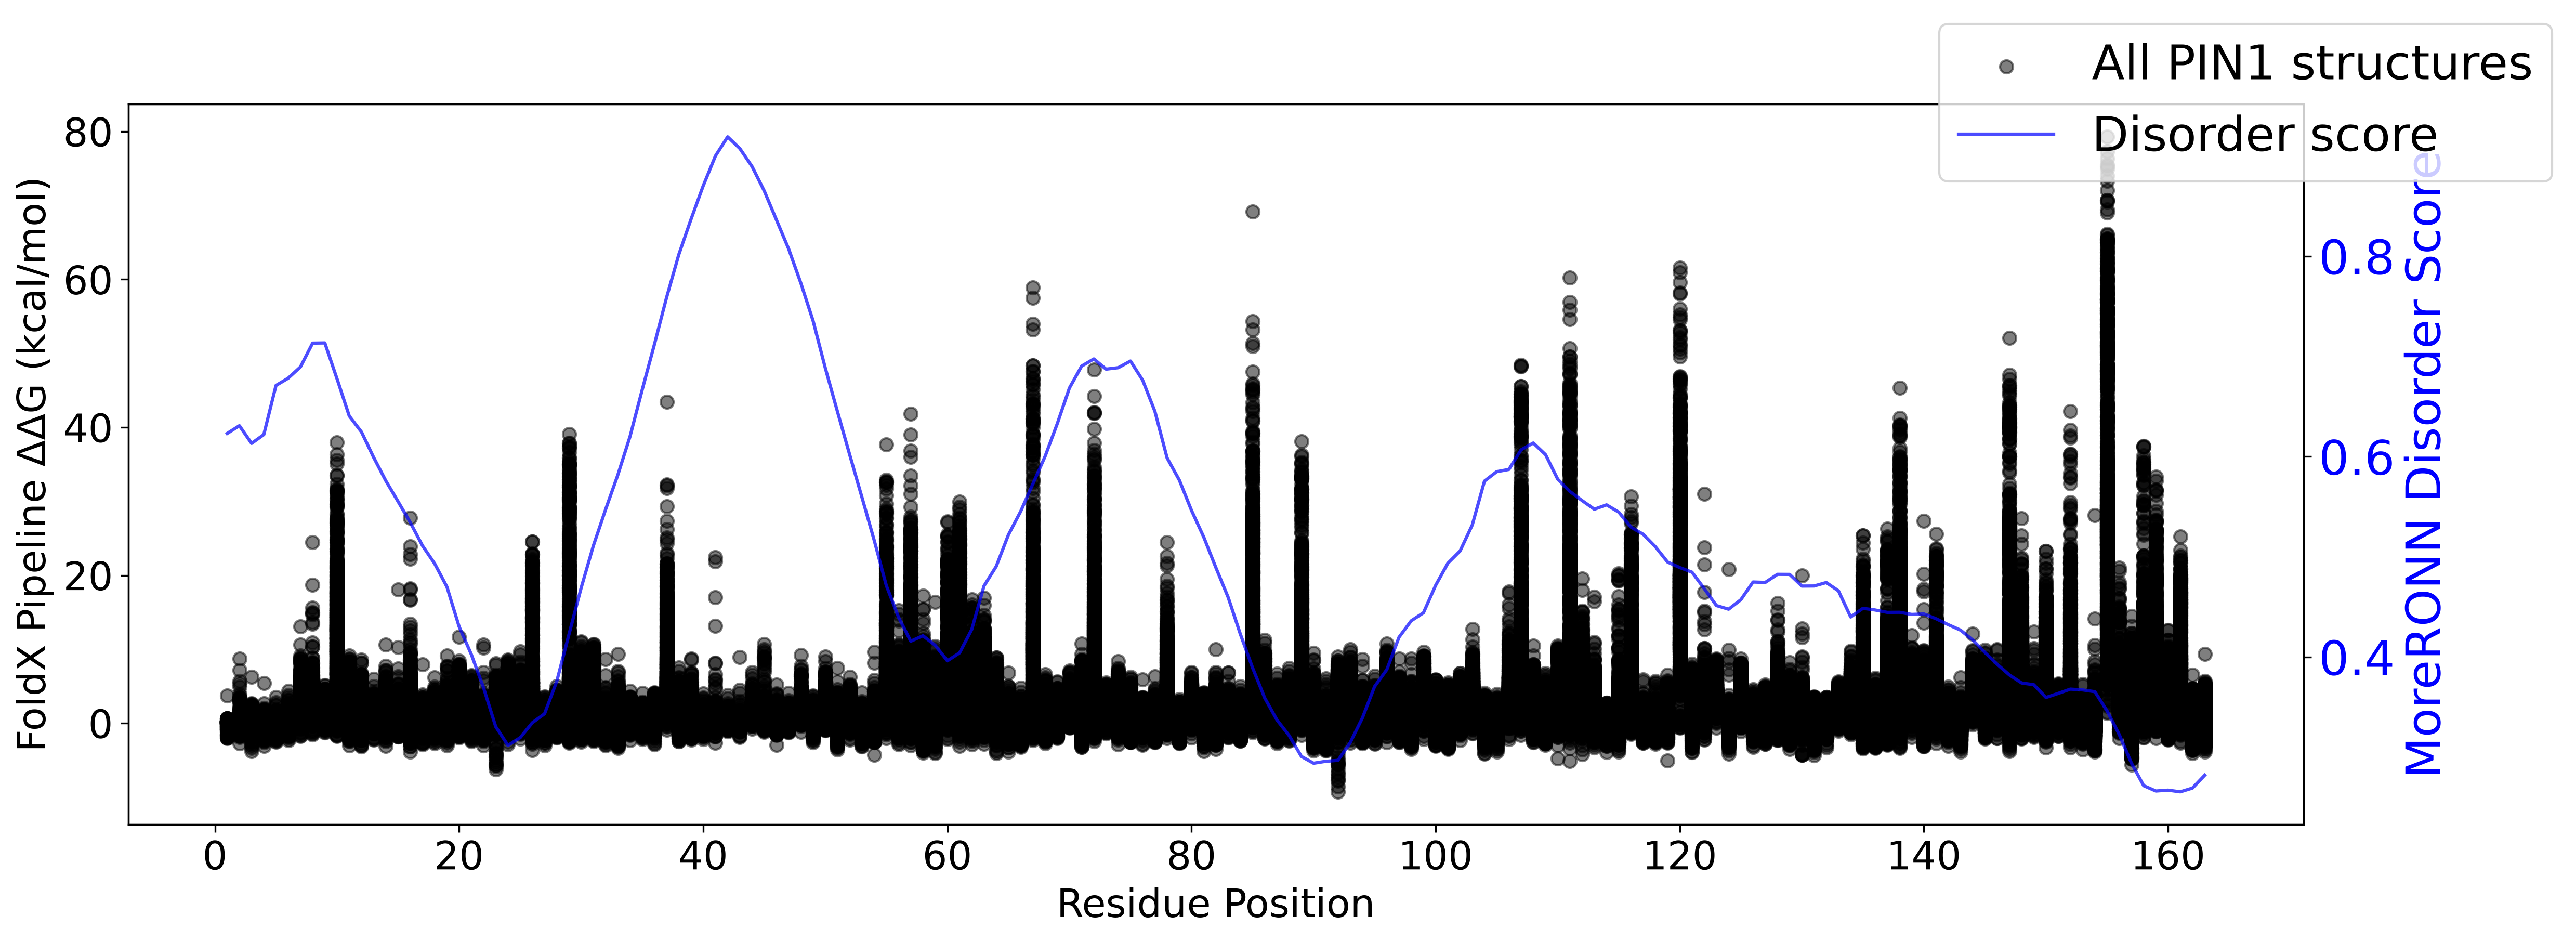

In [41]:
# Recreating full gene energies scatter with MoreRonn score overlaid

fig, ax1 = plt.subplots(figsize=(18, 6), dpi=300)
plt.rcParams.update({'font.size': 22})

# Scatter plot
plt.scatter(pipeline_data[uniprot_id]['res'], pipeline_data[uniprot_id]['ddg_rebased'], label=f'All {gene} structures', color='black', alpha=0.5)

ax1.set_xlabel('Residue Position')
ax1.set_ylabel('FoldX Pipeline ΔΔG (kcal/mol)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Line plot for Disorder Score on second y-axis
ax2 = ax1.twinx()
ax2.plot(MoreRONN_df['AApos'], MoreRONN_df['MoreRonn'], label='Disorder score', color='blue', alpha=0.7
)

ax2.set_ylabel('MoreRONN Disorder Score', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')


fig.legend()
plt.savefig("../Figures/Figure_S6c.png", dpi=300, bbox_inches="tight")

plt.show()


In [42]:
# Calculate variance in energies and add to MoreRonn data
# For spg and FYN do not include structures with extreme negative DDG rebasing
pipeline_data_meanhomo_byuniprotdf = pd.concat(list(pipeline_data_meanhomo[uniprot_id].values()), ignore_index=True)
variance_df = pipeline_data_meanhomo_byuniprotdf.groupby('res')['ddg_rebased'].var().reset_index()
variance_df = variance_df.rename(columns={'ddg_rebased': 'ddg_rebased_variance'})

MoreRONN_df = MoreRONN_df.merge(variance_df, left_on="AApos", right_on="res", how='left')
MoreRONN_df = MoreRONN_df.dropna(subset=["res"]).reset_index(drop=True)


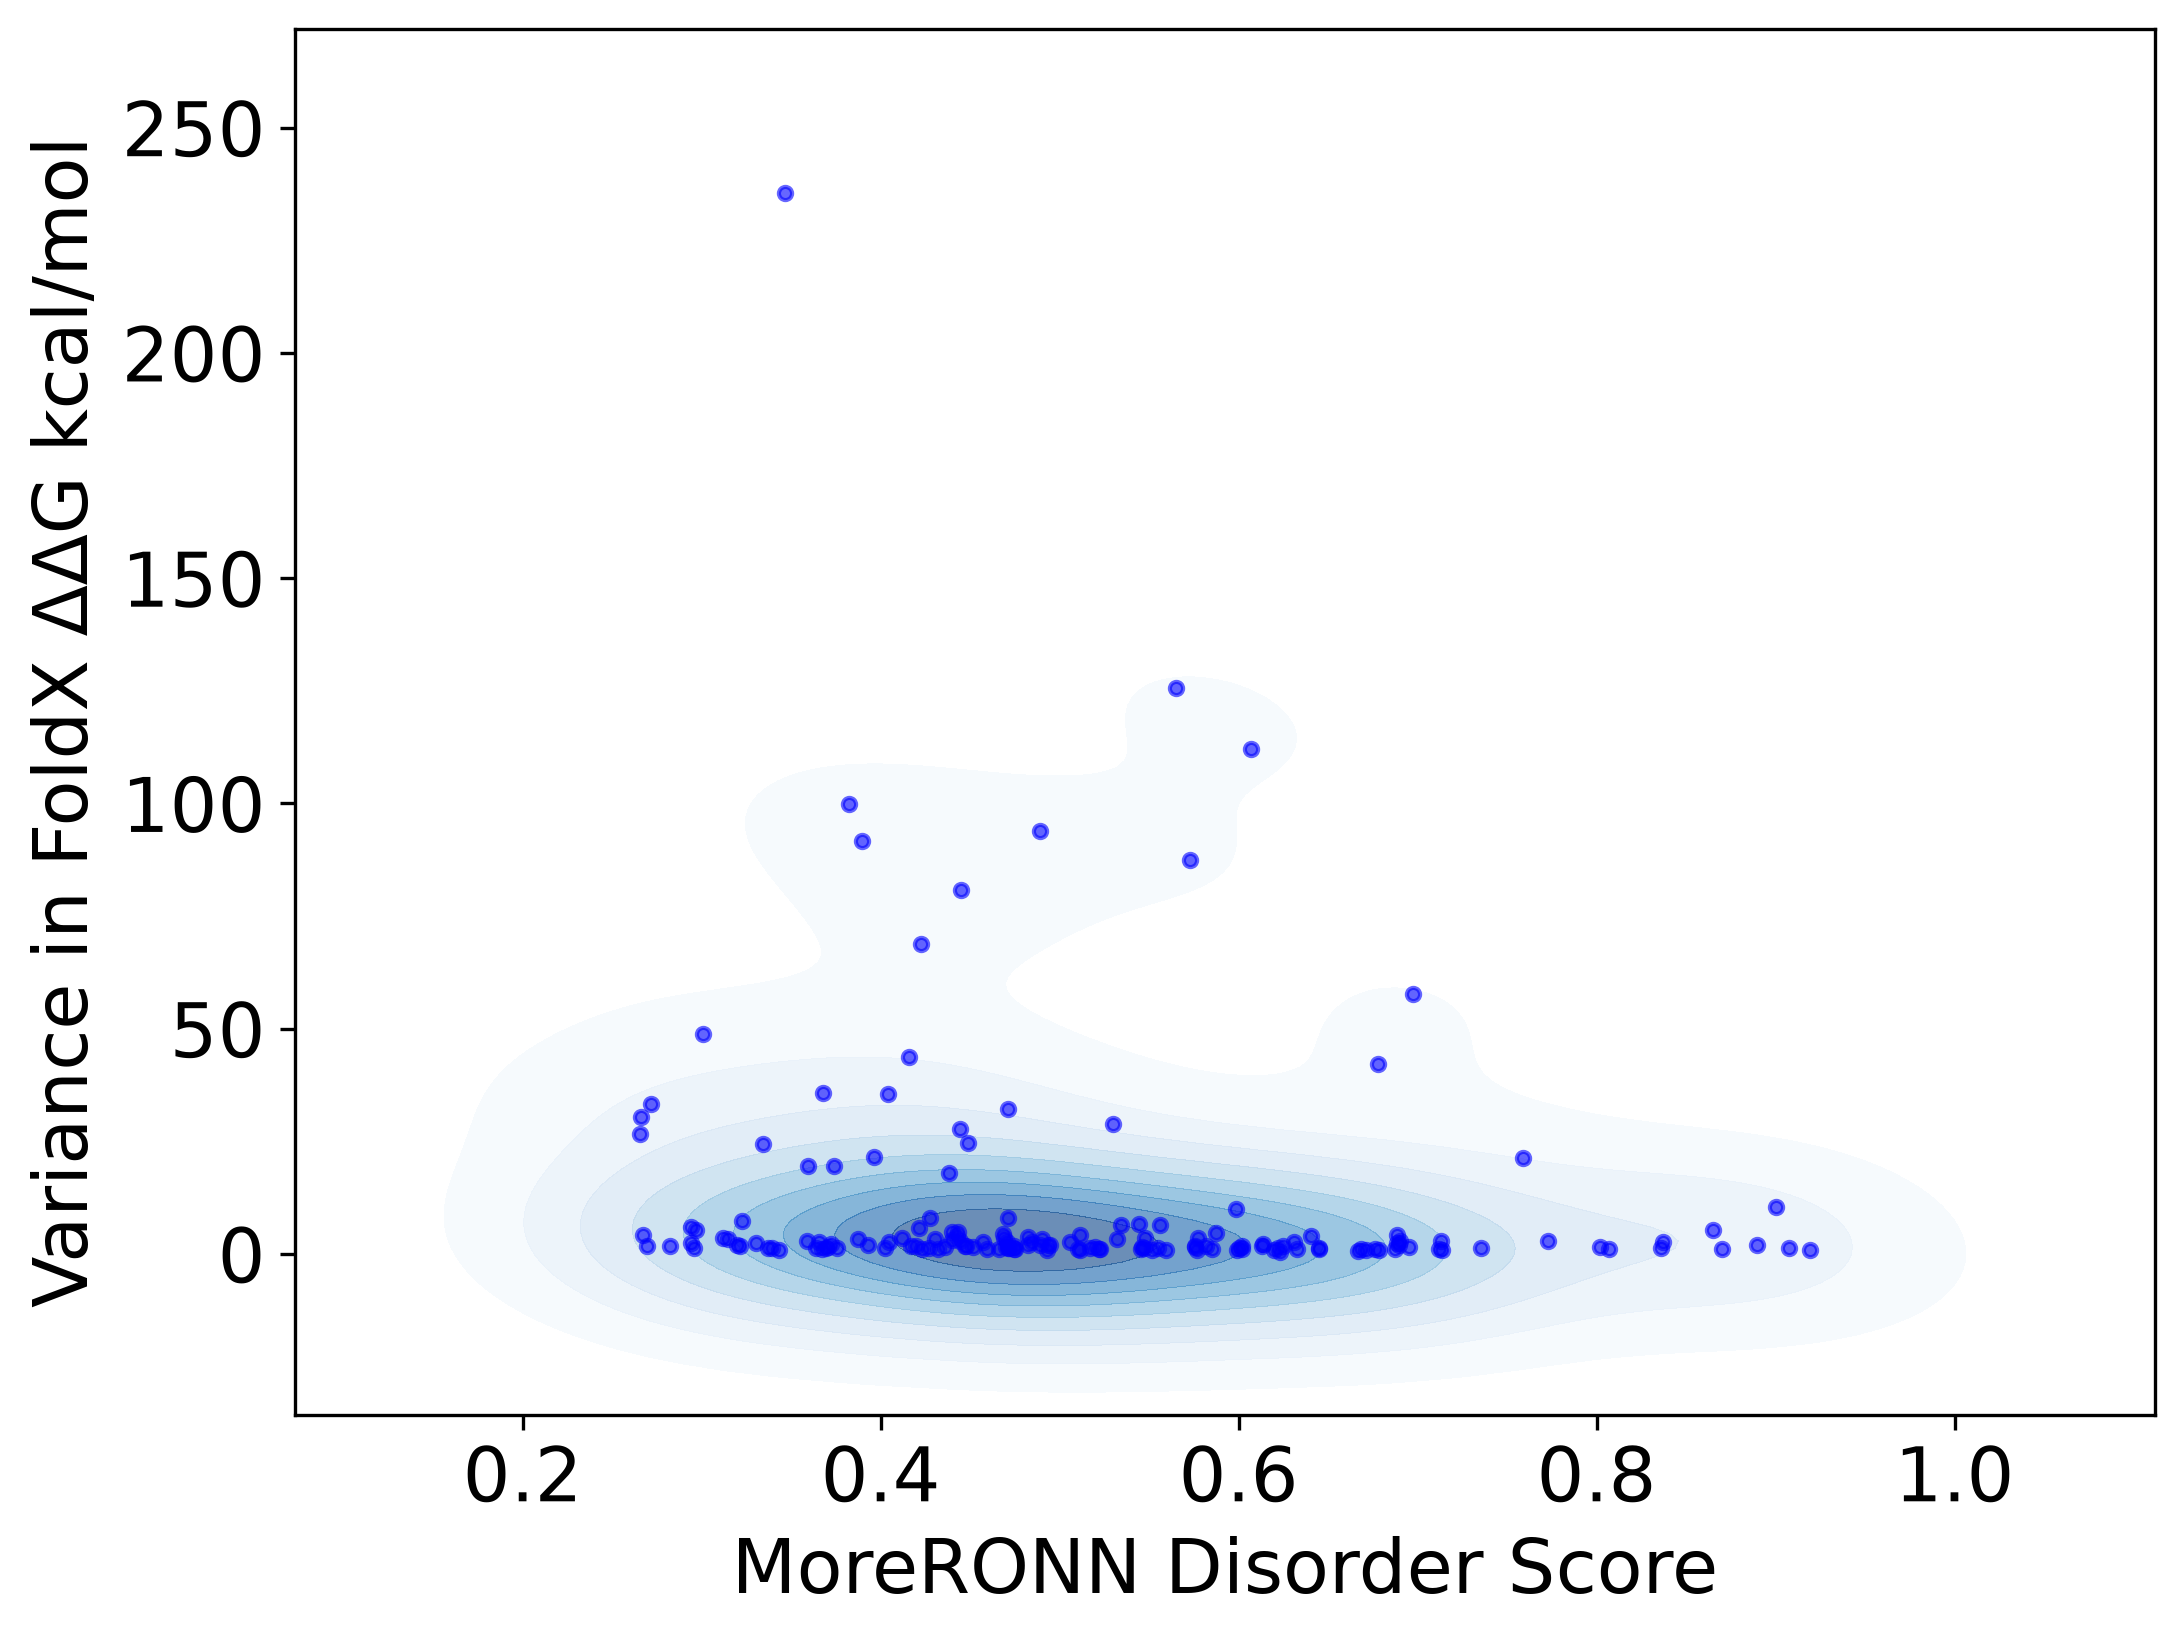

In [43]:
# KDE plot for disorder score v energy variance
plt.figure(figsize=(8, 6), dpi=300)
plt.rcParams.update({'font.size': 18})

 

sns.kdeplot(x=MoreRONN_df['MoreRonn'], y=MoreRONN_df['ddg_rebased_variance'], cmap='Blues', fill=True,alpha=0.6
)

# Scatter plot overlay
plt.scatter(MoreRONN_df['MoreRonn'], MoreRONN_df['ddg_rebased_variance'], color='blue', alpha=0.6, s=10 
)

# Add labels
plt.xlabel('MoreRONN Disorder Score')
plt.ylabel('Variance in FoldX ΔΔG kcal/mol')

# Show the plot
plt.savefig("../Figures/Figure_3c.png", dpi=300, bbox_inches="tight")


plt.show()

In [44]:
# Permutation test function

def permutation_test(data, column1, column2, num_permutations):
    # Calculate observed correlation
    obs_corr, _ = stats.stats.spearmanr(data[column1], data[column2])

    # Perform permutation test
    perm_corrs = []
    for _ in range(num_permutations):
        permuted_scores = np.random.permutation(data[column1].values)  # Shuffle the energy variance column
        perm_corr, _ = stats.stats.spearmanr(data[column2], permuted_scores)
        perm_corrs.append(perm_corr)

    # Compute p-value (two-tailed)
    p_value = np.mean(np.abs(perm_corrs) >= np.abs(obs_corr))
    
    return obs_corr, p_value

# Perform permuation test
obs_corr, p_value = permutation_test(MoreRONN_df, "MoreRonn", "ddg_rebased_variance", 10000)
print(f"Observed Correlation: {obs_corr:.3f}")
print(f"P-value: {p_value:.5f}\n")

C:\Users\zcemcel\AppData\Local\Temp\ipykernel_41168\1083637334.py:5: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  obs_corr, _ = stats.stats.spearmanr(data[column1], data[column2])
C:\Users\zcemcel\AppData\Local\Temp\ipykernel_41168\1083637334.py:11: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  perm_corr, _ = stats.stats.spearmanr(data[column2], permuted_scores)


Observed Correlation: -0.305
P-value: 0.00000



#### Elastic Network Model analysis (Prody)
Separate notebook as specific dependencies

In [45]:
ENM_10_df = pd.read_csv(f"../Output/ENM_dfs/ENM_{gene}_10fastest.csv")

In [46]:
# Chi-squared test: high variance mutations and fast modes of motions

# Add the variance in energies to the ENM dataframe
ENM_10_df = ENM_10_df.merge(variance_df, left_on="Residue", right_on="res", how='left')
ENM_10_df = ENM_10_df.dropna()

# Categorize the variance in energies and fast mode fluctuations
ENM_10_df['High Variance'] = ENM_10_df['ddg_rebased_variance'] > 20
ENM_10_df['Fastest Mode'] = ENM_10_df['Max Fluctuation (10 fastest modes)'] > 0.01

#Create the contingency table
contingency_table = pd.crosstab(ENM_10_df['High Variance'], ENM_10_df['Fastest Mode'], margins=True)

print("Contingency Table:")
print(contingency_table)

# Perform the Chi-Squared Test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table.iloc[:-1, :-1])  # Exclude the 'All' margin row/column

# Output the results
print("\nChi-squared test results:")
print(f"Chi2 Statistic: {chi2}")
print(f"p-value: {p}")


Contingency Table:
Fastest Mode   False  True  All
High Variance                  
False            115    11  126
True              18     7   25
All              133    18  151

Chi-squared test results:
Chi2 Statistic: 5.656512942408932
p-value: 0.017390665471970563


In [47]:
ENM_df = pd.read_csv(f"../Output/ENM_dfs/ENM_{gene}.csv")

In [48]:
# Add the variance in energies to the ENM dataframe
ENM_df = ENM_df.merge(variance_df, left_on="Residue", right_on="res", how='left')
ENM_df = ENM_df.dropna()


The best mode is 3 with AUC: 0.75


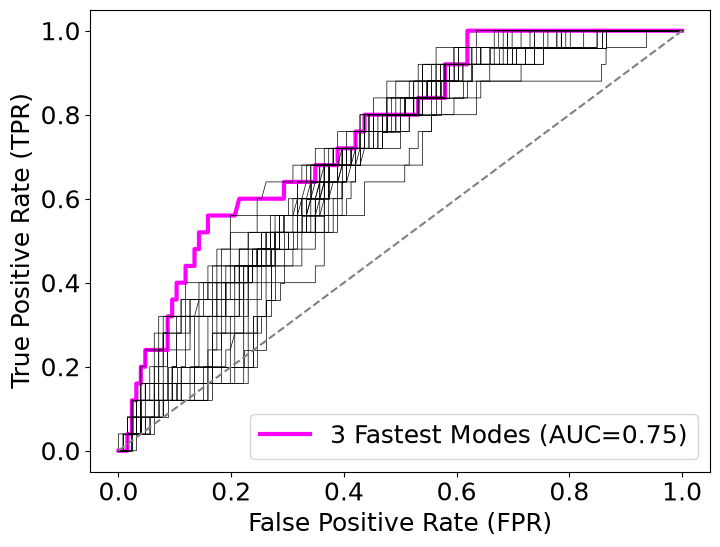

In [49]:
# Store results
fpr_list = []  # List to store False Positive Rates for each mode count
tpr_list = []  # List to store True Positive Rates for each mode count
auc_list = []  # List to store AUC scores for each mode count

# Variables to track the best AUC
best_auc = 0
best_mode = None
best_fpr = None
best_tpr = None
best_idx = None


for i in range(1, 31):  # Loop for columns 'Max Fluctuation (-1)' to 'Max Fluctuation (-30)'
    column_name = f'Max Fluctuation (-{i})'  
    
    if column_name in ENM_df.columns:
        # Define classification labels
        y_true = ENM_df['ddg_rebased_variance'] > 20  # True high variance
        y_pred = ENM_df[column_name] > 0.01  # Fastest mode threshold

        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_true, ENM_df[column_name])

        # Compute AUC
        auc_score = auc(fpr, tpr)

        # Append the values to lists
        fpr_list.append(fpr)
        tpr_list.append(tpr)
        auc_list.append(auc_score)

        # Track the best AUC and its corresponding mode
        if auc_score > best_auc:
            best_auc = auc_score
            best_mode = int(column_name.split('(-')[1].rstrip(')'))
            best_fpr = fpr
            best_tpr = tpr
            best_idx = len(auc_list) - 1

# Plot ROC curves for all modes
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 18})


for i in range(len(fpr_list)):
    if i == best_idx:
        plt.plot(
            fpr_list[i], tpr_list[i],
            label=f'{best_mode} Fastest Modes (AUC={best_auc:.2f})',
            color='magenta', linewidth=3
        )
    else:
        plt.plot(fpr_list[i], tpr_list[i], color='black', linewidth=0.5)

# Print the best mode and AUC
print(f"The best mode is {best_mode} with AUC: {best_auc:.2f}")

# Plot a diagonal line 
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()

plt.grid(False)
plt.savefig("../Figures/Figure_3d.png", dpi=300, bbox_inches="tight")

plt.show()



In [52]:
# Rank modes by AUC

# Rank modes by AUC
mode_auc_pairs = [(i+1, auc_list[i]) for i in range(30)]  # Pair modes with their AUC scores
sorted_mode_auc_pairs = sorted(mode_auc_pairs, key=lambda x: x[1], reverse=True)  # Sort by AUC score, descending

# Create a DataFrame from the modes and AUC scores
df = pd.DataFrame(mode_auc_pairs, columns=['Mode', 'AUC'])

# Save the DataFrame
df.to_csv(f'../Output/ENM_dfs/{gene}_AUC.csv', index=False) 



In [ ]:
# Read the CSV files for FYN, spg, and PIN1
FYN_AUC_df = pd.read_csv('../Output/ENM_dfs/FYN_AUC.csv')
spg_AUC_df = pd.read_csv('../Output/ENM_dfs/spg_AUC.csv')
PIN1_AUC_df = pd.read_csv('../Output/ENM_dfs/PIN1_AUC.csv')

# Extract the Modes and AUC from each DataFrame
fyn_modes = FYN_AUC_df['Mode']
fyn_auc = FYN_AUC_df['AUC']

spg_modes = spg_AUC_df['Mode']
spg_auc = spg_AUC_df['AUC']

pin1_modes = PIN1_AUC_df['Mode']
pin1_auc = PIN1_AUC_df['AUC']

# Plotting AUC vs Modes for all three datasets
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 18})


plt.plot(fyn_modes, fyn_auc, marker='o', linestyle='-', label='FYN', color='lightblue')
plt.plot(spg_modes, spg_auc, marker='o', linestyle='-', label='spg', color='lightgreen')
plt.plot(pin1_modes, pin1_auc, marker='o', linestyle='-', label='PIN1', color='lightpink')

plt.xlabel('Number of Modes')
plt.ylabel('AUC')
plt.legend()
plt.grid(False)
plt.savefig("..Figures/Figure_3e.png", dpi=300, bbox_inches="tight")

plt.show()

### Alphafold-PCA analysis

In [53]:
# Dictionary of pipeline file prefixes by gene for AF files
gene_file_prefixes = {
    "PIN1": "pin1",
    "spg": "p06654",
    "FYN": "p06241",
    "rplI": "rpli",
    "THO1": "tho1",
    "CPA2": "cpa2",
    "PRPF40A": "prpf40a",  
    "sucB": "p0afg6",
    "VIL1": "p02640",
    "YAP1": "p46937",
}


# Universal tool for dealing with amino acid conversion 
aaconv = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
     'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
     'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
     'ALA': 'A', 'VAL':'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M',
     'H1S': 'H', 'H2S': 'H'}

def convert_mutation(m):
    aa = m[:3]
    return aaconv.get(aa, aa) + m[3:]


In [54]:
pipeline_directory = "../Data/Pipeline/pipeline_short_incAF"

def load_af_pipeline_data(gene, directory_path, gene_file_prefixes):
    prefix = gene_file_prefixes.get(gene)

    file_names = os.listdir(directory_path)

    # find AF file for this gene
    gene_files = [
        f for f in file_names
        if f.startswith(prefix) and "_af" in f.lower()
    ]

    file_path = os.path.join(directory_path, gene_files[0])
    af_data = pd.read_csv(file_path)

    af_data["mut_from"] = af_data["mut_from"].apply(convert_mutation)
    af_data["mut_to"] = af_data["mut_to"].apply(convert_mutation)
    af_data["variant"] = (af_data["mut_from"].astype(str) + af_data["pdb_rid"].astype(str) + af_data["mut_to"].astype(str))

    af_data = af_data[
        ["pdb", "pdb_rid", "mut_to", "mut_from", "variant", "ddg"]
    ]
    af_data["uniprot_id"] = uniprot_id # to be compatible with pipeline data
    af_data.rename(columns={"pdb": "pdb_id"}, inplace=True)
    af_data.rename(columns={"pdb_rid": "res"}, inplace=True)
    af_data.rename(columns={"variant": "variant_rebased"}, inplace=True)
    af_data.rename(columns={"ddg": "ddg_rebased"}, inplace=True)

    return af_data


In [55]:
af_data = load_af_pipeline_data(
    gene="PIN1",
    directory_path=pipeline_directory,
    gene_file_prefixes=gene_file_prefixes
)


In [56]:
# Concatenate with pipeline data
pipeline_data_meanhomo[uniprot_id]["AF"] = af_data


In [57]:
# Define amino acids mapping
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_index = {aa: i for i, aa in enumerate(amino_acids)}

seq_len = 163 # hard coded!

matrices_list = []
pdb_ids_list = []

# Iterate through PDBs for a given UniProt
for pdb_id, df in pipeline_data_meanhomo[uniprot_id].items():
        
    # Map mutated amino acid to index
    df['aa_idx'] = df['variant_rebased'].str[-1].map(aa_index)
    
    # Create empty matrix
    matrix = np.zeros((len(amino_acids), seq_len))
    
    # Fill in DDG values
    for _, row in df.iterrows():
        pos = int(row['res']) - 1  # convert to 0-based
        aa_idx = row['aa_idx']
        ddg = row['ddg_rebased']
        matrix[aa_idx, pos] = ddg
    
    matrices_list.append(matrix)
    pdb_ids_list.append(pdb_id)

# Normalise matrices
scaler = StandardScaler()
normalised_matrices_list = []

for mat in matrices_list:
    mat_2d = mat.reshape(-1, 1)
    norm_mat = scaler.fit_transform(mat_2d).reshape(mat.shape)
    normalised_matrices_list.append(norm_mat)

# Concatenate along sequence axis (columns)
concatenated_matrix = np.concatenate(normalised_matrices_list, axis=1)
reshaped_array = concatenated_matrix.T.reshape(len(matrices_list), -1)

print(f"Number of matrices: {len(matrices_list)}")


Number of matrices: 97


In [58]:
# Compute covariance matrix and eigenvalues
covariance_matrix = np.cov(reshaped_array, rowvar=False)

u, s, vh = np.linalg.svd(covariance_matrix)
eigenvalues = s**2
variance_explained = eigenvalues / np.sum(eigenvalues)

print("Variance explained (top 2 PCs):")
for i in range(2):
    print(f"PC{i+1}: {variance_explained[i]*100:.2f}%")

Variance explained (top 2 PCs):
PC1: 95.01%
PC2: 1.97%


In [59]:
# Project onto top 2 eigenvectors
top_eigvecs = u[:, :2]
pc_scores = reshaped_array @ top_eigvecs   # (n_structures, 2)


In [60]:
# Separate structures
# PIN1: short chain, long chain, both/fully resolved

dfs = pipeline_data_meanhomo[uniprot_id]

# First, compute min and max residue positions per PDB/AF structure
pos_stats = {}
for pdb_id, df in dfs.items():
    min_res = df['res'].min()
    max_res = df['res'].max()
    pos_stats[pdb_id] = {'min': min_res, 'max': max_res}

# Now create subsets by residue coverage
short_structures = {}
long_structures = {}
both_structures = {}

for pdb_id, df in dfs.items():
    min_res = pos_stats[pdb_id]['min']
    max_res = pos_stats[pdb_id]['max']

    if max_res < 100:
        short_structures[pdb_id] = df
    elif max_res > 100 and min_res > 40:
        long_structures[pdb_id] = df
    elif max_res > 100 and min_res < 50:
        both_structures[pdb_id] = df

print("Short:", list(short_structures.keys()))
print("Long:", list(long_structures.keys()))
print("Both:", list(both_structures.keys()))


Short: ['1I6C', '1I8G', '1I8H', '2KBU', '2KCF', '2LB3', '2M8I', '2M8J', '2M9E', '2M9F', '2M9I', '2M9J', '2N1O', '4GWT', '4GWV', '5B3W', '5B3X', '5B3Y', '5B3Z', '5BMY', '5VTI', '5VTJ', '5VTK', '6SVC', '6SVE', '6SVH']
Long: ['1NMW', '2RUC', '2RUD', '2RUQ', '2RUR', '3I6C', '3IK8', '3IKD', '3IKG', '3JYJ', '3KAC', '4TNS', '4TYO', '5GPH', '6DUN']
Both: ['1F8A', '1NMV', '1PIN', '1ZCN', '2F21', '2ITK', '2Q5A', '2XP3', '2XP4', '2XP5', '2XP6', '2XP7', '2XP8', '2XP9', '2XPA', '2XPB', '2ZQS', '2ZQT', '2ZQU', '2ZQV', '2ZR4', '2ZR5', '2ZR6', '3KAB', '3KAD', '3KAF', '3KAG', '3KAH', '3KAI', '3KCE', '3NTP', '3ODK', '3OOB', '3TC5', '3TCZ', '3TDB', '3WH0', '4QIB', '4U84', '4U85', '4U86', '5UY9', '6O33', '6O34', '6VAJ', '7EFJ', '7EFX', '7EKV', '7F0M', '7SA5', '7SUQ', '7SUR', '8SG2', '8VJF', '9IT1', 'AF']


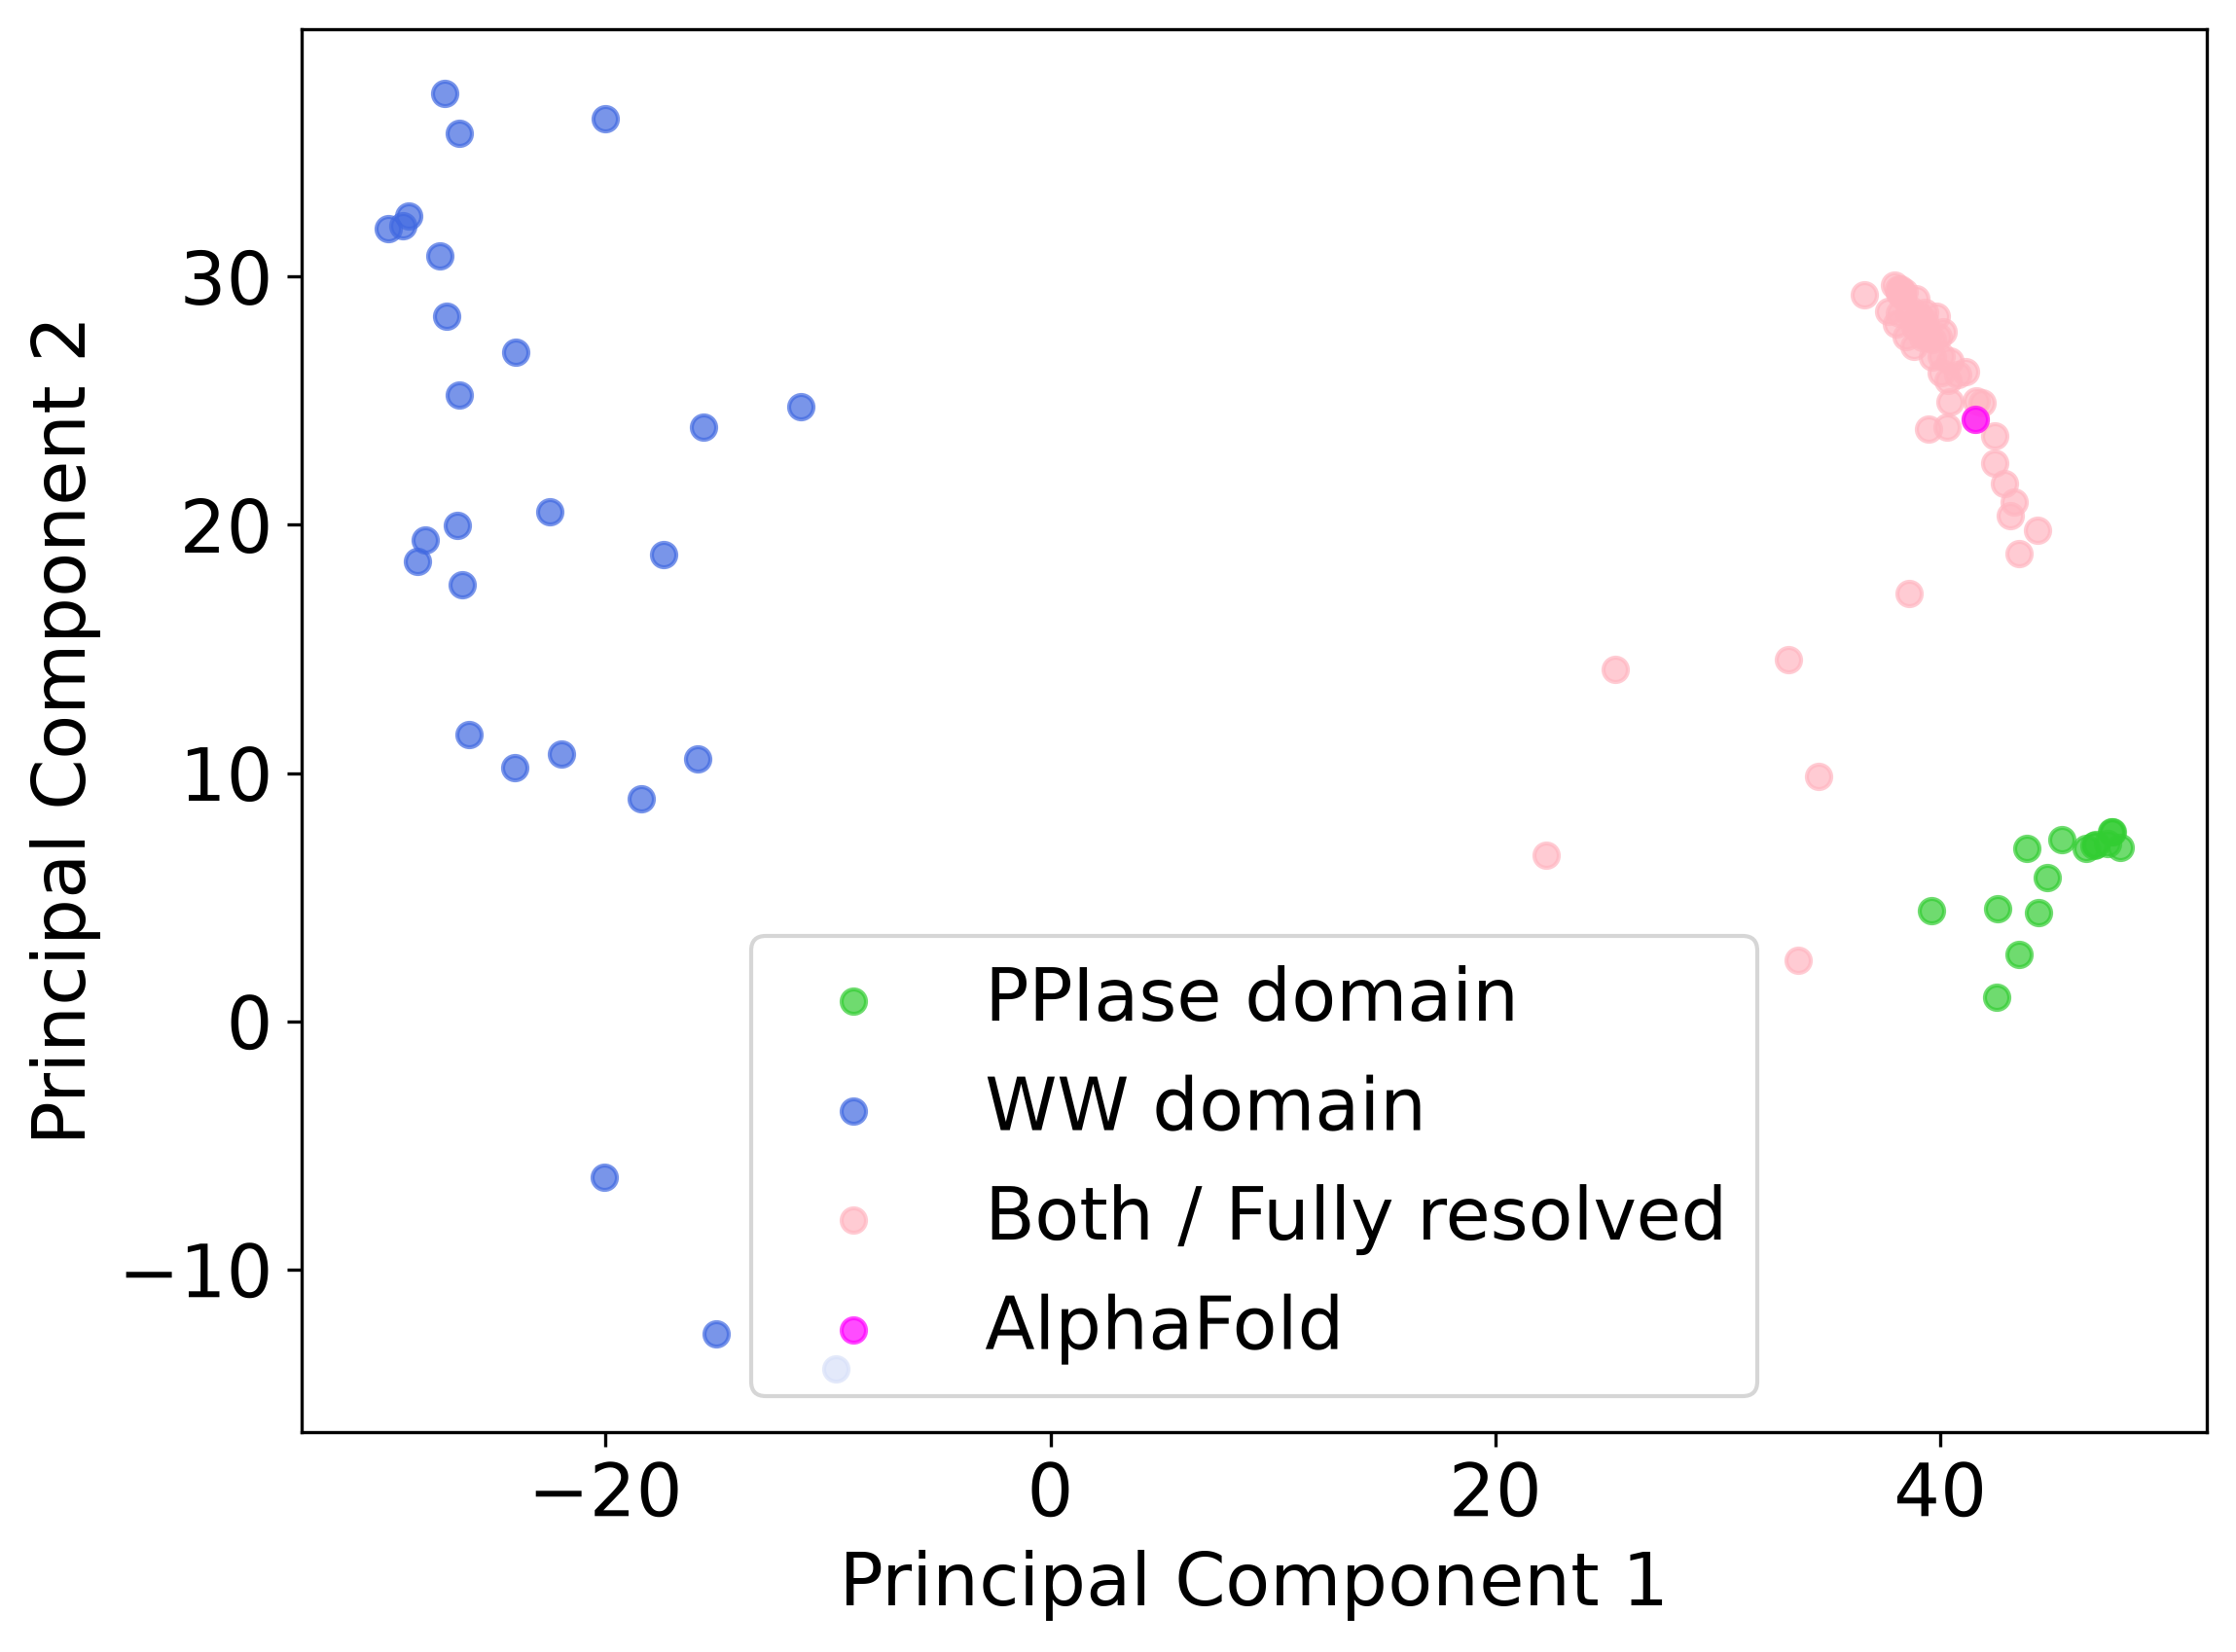

In [62]:
# Merge results to dataframe and plot

plt.rcParams.update({'font.size': 18})

pca_df = pd.DataFrame({
    'pdb_id': pdb_ids_list,
    'PC1_Value': pc_scores[:, 0],
    'PC2_Value': pc_scores[:, 1]
})

short_ids = set(short_structures.keys())
long_ids = set(long_structures.keys())
both_ids = set(both_structures.keys())
af_id = set(['AF'])


plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(pca_df[pca_df['pdb_id'].isin(long_ids)]['PC1_Value'], 
            pca_df[pca_df['pdb_id'].isin(long_ids)]['PC2_Value'],
            color='limegreen', label='PPIase domain', alpha=0.7)

plt.scatter(pca_df[pca_df['pdb_id'].isin(short_ids)]['PC1_Value'], 
            pca_df[pca_df['pdb_id'].isin(short_ids)]['PC2_Value'],
            color='royalblue', label='WW domain', alpha=0.7)

plt.scatter(pca_df[pca_df['pdb_id'].isin(both_ids)]['PC1_Value'], 
            pca_df[pca_df['pdb_id'].isin(both_ids)]['PC2_Value'],
            color='lightpink', label='Both / Fully resolved', alpha=0.7)

plt.scatter(pca_df[pca_df['pdb_id'].isin(af_id)]['PC1_Value'], 
            pca_df[pca_df['pdb_id'].isin(af_id)]['PC2_Value'],
            color='magenta', label='AlphaFold', alpha=0.7)


plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig("../Figures/Figure_1b.png", dpi=300, bbox_inches="tight")

plt.show()

#### Alphafold - correlation 

In [63]:

def load_af_pipeline_data_fixed(gene, uniprot_id, directory_path, gene_file_prefixes):
    prefix = gene_file_prefixes.get(gene)
    file_names = os.listdir(directory_path)
    gene_files = [f for f in file_names if f.startswith(prefix) and "_af" in f.lower()]
    if not gene_files:
        return None
    af_data = pd.read_csv(os.path.join(directory_path, gene_files[0]))
    af_data["mut_from"] = af_data["mut_from"].apply(convert_mutation)
    af_data["mut_to"] = af_data["mut_to"].apply(convert_mutation)
    af_data["variant"] = af_data["mut_from"].astype(str) + af_data["pdb_rid"].astype(str) + af_data["mut_to"].astype(str)
    af_data = af_data[["pdb", "pdb_rid", "mut_to", "mut_from", "variant", "ddg"]]
    af_data["uniprot_id"] = uniprot_id
    af_data = af_data.rename(columns={"pdb": "pdb_id", "pdb_rid": "res"})
    return af_data


# AF-only vs Rocklin1 (high-agreement)
af_only_results = []
for gene, uid in uniprot_ids.items():
    af_data = load_af_pipeline_data_fixed(gene, uid, pipeline_directory, gene_file_prefixes)
    if af_data is None:
        continue

    rocklin_df = Rocklin1_data.get(uid)
    if rocklin_df is None:
        continue

    merged = af_data.merge(rocklin_df[["variant", "deltaG", "prev_dG"]], on="variant", how="inner")
    if merged.shape[0] < 5 or merged["ddg"].std() == 0:
        continue

    r, _ = pearsonr(merged["ddg"], -merged["deltaG"])
    af_only_results.append({"gene": gene, "uniprot_id": uid, "n_variants": merged.shape[0], "af_only_r": r})

af_only_df = pd.DataFrame(af_only_results)
af_only_df

,gene,uniprot_id,n_variants,af_only_r
0,PIN1,Q13526,60,0.381244
1,spg,P06654,886,0.498715
2,FYN,P06241,108,0.422585
3,rplI,P02417,42,0.650684
4,THO1,P40040,28,0.766974
5,CPA2,P48052,20,0.207432
6,PRPF40A,O75400,47,0.478175


### FoldX vs RaSP

In [64]:
gene = 'PIN1'

In [65]:
# Load RaSP and build it same way as FoldX pipeline data
f = os.path.join("../Output/Aligned_dfs", f"rasp_{uniprot_id}.csv")
df = pd.read_csv(f)
df["res"] = df["res"].astype(int)
df["variant_rebased"] = df["mut_from_rebased"].astype(str) + df["res"].astype(str) + df["mut_to"].astype(str)
df["uniprot_id"] = uniprot_id
df["ddg_rebased"] = df["score_ml_rebased"]   # so RaSP can be handled exactly like FoldX
rasp_data = {uniprot_id: df}

rasp_data_meanhomo = defaultdict(dict)
for pdb_id, pdb_df in df.groupby("pdb_id"):
    rasp_data_meanhomo[uniprot_id][pdb_id] = (
        pdb_df.groupby(["uniprot_id", "pdb_id", "variant_rebased"], as_index=False)
              .agg({"ddg_rebased": "mean", "mut_from_rebased": "first", "mut_to": "first", "res": "first"})
    )

rocklin_vars = Rocklin1_data[uniprot_id][["variant", "deltaG", "prev_dG"]]
rasp_combined = (
    pd.concat(rasp_data_meanhomo[uniprot_id].values(), ignore_index=True)
      .merge(rocklin_vars, left_on="variant_rebased", right_on="variant", how="left")
      .dropna(subset=["deltaG"])
)
rasp_combined_data = {uniprot_id: rasp_combined}

In [66]:
def evaluate(uid, excl_fx, excl_rasp, match=True, filter_pooled=True):
    """Compare FoldX and RaSP against Tsuboyama (deltaG) for one gene.
    match=True     -> both methods scored on the same substitutions (scored by both, not excluded
                      in either) AND the same structures (present in both).
    filter_pooled  -> True: pooled r uses the exclusions (and matching).
                      False: pooled r uses ALL substitutions (as in current Table S2).
    Aggregated r (per-substitution median) always uses the exclusions."""
    fx, rs = combined_data[uid], rasp_combined_data[uid]
    fx_all, rs_all = fx, rs                                   # before any exclusion
    excl_fx, excl_rasp = set(excl_fx), set(excl_rasp)

    if match:
        keep = (set(fx["variant_rebased"]) & set(rs["variant_rebased"])) - excl_fx - excl_rasp
        shared = set(fx["pdb_id"]) & set(rs["pdb_id"])
        fx = fx[fx["variant_rebased"].isin(keep) & fx["pdb_id"].isin(shared)]
        rs = rs[rs["variant_rebased"].isin(keep) & rs["pdb_id"].isin(shared)]
    else:
        fx = fx[~fx["variant_rebased"].isin(excl_fx)]
        rs = rs[~rs["variant_rebased"].isin(excl_rasp)]

    p_fx, p_rs = (fx, rs) if filter_pooled else (fx_all, rs_all)

    def pooled_r(d):                      # one r over all structure-level predictions
        return pearsonr(-d["deltaG"], d["ddg_rebased"])[0]

    def aggregated_r(d):                  # per-substitution median across structures
        m = d.groupby("variant_rebased").agg(e=("ddg_rebased", "median"), dG=("deltaG", "first"))
        return pearsonr(-m["dG"], m["e"])[0], len(m)

    agg_fx, n_fx = aggregated_r(fx)
    agg_rs, n_rs = aggregated_r(rs)

    # FoldX vs RaSP agreement over ALL substitutions (inner merge => shared structures only)
    keys = ["pdb_id", "pdb_chain", "res", "mut_to"]
    pooled = pipeline_data[uid][keys + ["variant_rebased", "ddg_rebased"]].merge(
        rasp_data[uid][keys + ["ddg_rebased"]], on=keys, suffixes=("_fx", "_rasp"))
    pooled = pooled[~pooled["variant_rebased"].isin(excl_fx | excl_rasp)]

    return {
        "structures used (FoldX/RaSP)": f"{fx['pdb_id'].nunique()}/{rs['pdb_id'].nunique()}",
        "substitutions (FoldX/RaSP)": f"{n_fx}/{n_rs}",
        "pooled r FoldX": pooled_r(p_fx), "pooled r RaSP": pooled_r(p_rs),
        "aggregated r FoldX": agg_fx, "aggregated r RaSP": agg_rs,
        "FoldX vs RaSP agreement (pooled r)": pearsonr(pooled["ddg_rebased_fx"], pooled["ddg_rebased_rasp"])[0],
    }

In [72]:
gene = next(k for k, v in uniprot_ids.items() if v == uniprot_id)   # label always matches the data

# FoldX problem substitutions: reuse `top_mutations` from the outlier cell (same gene).
fx_prob = top_mutations

print(f"{gene}: removing {len(fx_prob)} FoldX problem substitutions: {fx_prob}")

schemes = {
    "Current Table S2 (FoldX removal only)":         (fx_prob, [],      False, False),
    "FoldX problem substitutions removed from both": (fx_prob, fx_prob, True,  True),
}
n_structs_total = f"{pipeline_data[uniprot_id]['pdb_id'].nunique()}/{rasp_data[uniprot_id]['pdb_id'].nunique()}"

tableS2_fair = pd.DataFrame([
    {"protein": gene, "structures total (FoldX/RaSP)": n_structs_total, "scheme": name,
     **evaluate(uniprot_id, ex_fx, ex_rs, match, fp)}
    for name, (ex_fx, ex_rs, match, fp) in schemes.items()
]).set_index(["protein", "scheme"]).round(2)

tableS2_fair

PIN1: removing 4 FoldX problem substitutions: ['T29D', 'G10A', 'P37I', 'W11F']


structures total (FoldX/RaSP)  \
protein scheme                                                                        
PIN1    Current Table S2 (FoldX removal only)                                 96/94   
        FoldX problem substitutions removed from both                         96/94   

                                                      structures used (FoldX/RaSP)  \
protein scheme                                                                       
PIN1    Current Table S2 (FoldX removal only)                                81/79   
        FoldX problem substitutions removed from both                        79/79   

                                                      substitutions (FoldX/RaSP)  \
protein scheme                                                                     
PIN1    Current Table S2 (FoldX removal only)                              56/60   
        FoldX problem substitutions removed from both                      56/56   

                                                       pooled r FoldX  \
protein scheme                                                          
PIN1    Current Table S2 (FoldX removal only)                    0.30   
        FoldX problem substitutions removed from both            0.35   

                                                       pooled r RaSP  \
protein scheme                                                         
PIN1    Current Table S2 (FoldX removal only)                   0.58   
        FoldX problem substitutions removed from both           0.60   

                                                       aggregated r FoldX  \
protein scheme                                                              
PIN1    Current Table S2 (FoldX removal only)                        0.60   
        FoldX problem substitutions removed from both                0.61   

                                                       aggregated r RaSP  \
protein scheme                                                             
PIN1    Current Table S2 (FoldX removal only)                       0.66   
        FoldX problem substitutions removed from both               0.67   

                                                       FoldX vs RaSP agreement (pooled r)  
protein scheme                                                                             
PIN1    Current Table S2 (FoldX removal only)                                        0.49  
        FoldX problem substitutions removed from both                                0.49